# 金利ボラティリティモデルの学習ノートブック
## Chapter 0-2: 基礎概念とBlack76・Bachelier

このノートブックは、金利ボラティリティモデルを直感と数式、シミュレーション、可視化を通じて学ぶためのものです。

## Chapter 0: Yield Curve Basics

金利モデルを理解する前に、ディスカウント、フォワードレート、スワップレートの基本概念を整理します。

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# 日本語フォントの設定（必要に応じて）
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed
np.random.seed(42)

# ===== Basic Functions =====
def discount_factor(zero_rate, T):
    """Discount factor from zero rate"""
    return np.exp(-zero_rate * T)

def zero_rate_from_discount(df, T):
    """Zero rate from discount factor"""
    if T <= 0 or df <= 0:
        return 0
    return -np.log(df) / T

def forward_rate(zero_rates, T1, T2, T_array):
    """Forward rate f(T1, T2) from zero curve"""
    z1 = np.interp(T1, T_array, zero_rates)
    z2 = np.interp(T2, T_array, zero_rates)
    if T2 == T1:
        return z2
    return (z2 * T2 - z1 * T1) / (T2 - T1)

# ===== Yield Curve Scenarios =====
T_array = np.linspace(0.5, 10, 50)

# Flat curve
flat_zero = np.ones_like(T_array) * 0.02

# Upward sloping
upward_zero = 0.02 + 0.01 * (1 - np.exp(-T_array / 5))

# Inverted
inverted_zero = 0.03 - 0.01 * (1 - np.exp(-T_array / 3))

# Compute discount factors
flat_df = discount_factor(flat_zero, T_array)
upward_df = discount_factor(upward_zero, T_array)
inverted_df = discount_factor(inverted_zero, T_array)

# Compute forward rates (instantaneous)
flat_fwd = np.gradient(flat_zero) / np.gradient(T_array) + flat_zero
upward_fwd = np.gradient(upward_zero) / np.gradient(T_array) + upward_zero
inverted_fwd = np.gradient(inverted_zero) / np.gradient(T_array) + inverted_zero

print("Ch0: Yield Curve Basics")
print("=" * 60)
print(f"Flat curve: 0% to {flat_zero[-1]*100:.2f}%")
print(f"Upward curve: {upward_zero[0]*100:.2f}% to {upward_zero[-1]*100:.2f}%")
print(f"Inverted curve: {inverted_zero[0]*100:.2f}% to {inverted_zero[-1]*100:.2f}%")


Ch0: Yield Curve Basics
Flat curve: 0% to 2.00%
Upward curve: 2.10% to 2.86%
Inverted curve: 2.85% to 2.04%


## Chapter 1: Black 76 Model

Forward rateのオプション価格付けモデル。基本式：
$$dF_t = \sigma_B F_t dW_t$$

特徴：
- Forward rate が正であることを前提
- Lognormal分布
- 相対ボラティリティ (Black volatility)

In [40]:
# ===== Black 76 Formulas =====
def black76_price(F, K, T, vol, P=1.0):
    """Black 76 call option price"""
    if vol <= 0 or T <= 0 or F <= 0 or K <= 0:
        return max(F - K, 0) * P
    d1 = (np.log(F/K) + 0.5*vol**2*T) / (vol*np.sqrt(T))
    d2 = d1 - vol*np.sqrt(T)
    return P * (F*norm.cdf(d1) - K*norm.cdf(d2))

def black76_delta(F, K, T, vol, P=1.0):
    """Black 76 delta"""
    if vol <= 0 or T <= 0 or F <= 0:
        return 1.0 if F > K else 0.0
    d1 = (np.log(F/K) + 0.5*vol**2*T) / (vol*np.sqrt(T))
    return P * norm.cdf(d1)

def black76_gamma(F, K, T, vol, P=1.0):
    """Black 76 gamma (per 1% move)"""
    if vol <= 0 or T <= 0 or F <= 0:
        return 0.0
    d1 = (np.log(F/K) + 0.5*vol**2*T) / (vol*np.sqrt(T))
    return P * norm.pdf(d1) / (F * vol * np.sqrt(T))

def black76_vega(F, K, T, vol, P=1.0):
    """Black 76 vega (per 1% vol change)"""
    if vol <= 0 or T <= 0 or F <= 0:
        return 0.0
    d1 = (np.log(F/K) + 0.5*vol**2*T) / (vol*np.sqrt(T))
    return P * F * norm.pdf(d1) * np.sqrt(T) * 0.01

# Test
F, K, T, vol = 0.05, 0.05, 1.0, 0.20
price = black76_price(F, K, T, vol)
delta = black76_delta(F, K, T, vol)
gamma = black76_gamma(F, K, T, vol)
vega = black76_vega(F, K, T, vol)

print("Ch1: Black 76 Model")
print("=" * 60)
print(f"Forward: {F*100:.1f}%, Strike: {K*100:.1f}%, T: {T:.1f}y, Vol: {vol*100:.1f}%")
print(f"Price:  {price*10000:.4f} bps")
print(f"Delta:  {delta:.4f}")
print(f"Gamma:  {gamma:.6f} (per 1%)")
print(f"Vega:   {vega:.6f} (per 1% vol)")

Ch1: Black 76 Model
Forward: 5.0%, Strike: 5.0%, T: 1.0y, Vol: 20.0%
Price:  39.8278 bps
Delta:  0.5398
Gamma:  39.695255 (per 1%)
Vega:   0.000198 (per 1% vol)


## Chapter 2: Bachelier / Normal Model

Forward rateの絶対ボラティリティモデル。基本式：
$$dF_t = \sigma_N dW_t$$

特徴：
- 絶対ボラティリティ (Normal volatility)
- マイナス金利に対応
- 低金利環境で Black vol より安定

In [41]:
# ===== Bachelier Formulas =====
def bachelier_price(F, K, T, vol_normal, P=1.0):
    """Bachelier caplet price"""
    if vol_normal <= 0 or T <= 0:
        return max(F - K, 0) * P
    d = (F - K) / (vol_normal * np.sqrt(T))
    return P * ((F - K)*norm.cdf(d) + vol_normal*np.sqrt(T)*norm.pdf(d))

def bachelier_delta(F, K, T, vol_normal, P=1.0):
    """Bachelier delta"""
    d = (F - K) / (vol_normal * np.sqrt(T))
    return P * norm.cdf(d)

def bachelier_gamma(F, K, T, vol_normal, P=1.0):
    """Bachelier gamma"""
    d = (F - K) / (vol_normal * np.sqrt(T))
    return P * norm.pdf(d) / (vol_normal * np.sqrt(T))

def bachelier_vega(F, K, T, vol_normal, P=1.0):
    """Bachelier vega (price change per unit vol change)"""
    if vol_normal <= 0 or T <= 0:
        return 0.0
    d = (F - K) / (vol_normal * np.sqrt(T))
    return P * np.sqrt(T) * norm.pdf(d)

# Test
F, K, T, vol_n = 0.02, 0.02, 1.0, 0.005
price_b = bachelier_price(F, K, T, vol_n)
delta_b = bachelier_delta(F, K, T, vol_n)
vega_b = bachelier_vega(F, K, T, vol_n)

print("Ch2: Bachelier / Normal Model")
print("=" * 60)
print(f"Forward: {F*100:.1f}%, Strike: {K*100:.1f}%, T: {T:.1f}y")
print(f"Normal Vol: {vol_n*10000:.0f} bps")
print(f"Price:  {price_b*10000:.4f} bps")
print(f"Delta:  {delta_b:.4f}")
print(f"Vega:   {vega_b:.6f} (per 1bp vol)")

Ch2: Bachelier / Normal Model
Forward: 2.0%, Strike: 2.0%, T: 1.0y
Normal Vol: 50 bps
Price:  19.9471 bps
Delta:  0.5000
Vega:   0.398942 (per 1bp vol)



# Chapter 3: Vasicek Model

## 概要

**Vasicek Model** は、短期金利（short rate）の **平均回帰** (mean reversion) 動学を記述する最初の重要なモデルです。

### 特徴
- 短期金利 $r_t$ が確率的に動く
- 長期平均 $b$ に向かってドリフト
- ガウス過程（マイナス金利も許す）

## 基本式

$$dr_t = a(b - r_t)dt + \sigma dW_t$$

**パラメータの意味:**
- $a$ = Mean reversion speed（大きいほど素早く平均に戻る）
- $b$ = Long-term mean（目標金利）
- $\sigma$ = Volatility（ランダムショックの大きさ）

## 解析解

$$r_t = b + (r_0 - b)e^{-at} + \sigma\int_0^t e^{-a(t-s)} dW_s$$

期待値：$E[r_t] = b + (r_0 - b)e^{-at}$

分散：$V[r_t] = \frac{\sigma^2}{2a}(1 - e^{-2at})$

長期分散：$\lim_{t\to\infty} V[r_t] = \frac{\sigma^2}{2a}$
    

In [42]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def vasicek_path_euler(r0, a, b, sigma, T, n_steps, n_paths=1000):
    """
    Vasicek SDE を Euler-Maruyama スキームで simulation
    
    dr_t = a(b - r_t)dt + sigma * dW_t
    """
    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = r0
    
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        paths[:, i+1] = paths[:, i] + a * (b - paths[:, i]) * dt + sigma * dW
    
    return paths

def vasicek_path_analytical(r0, a, b, sigma, T, n_steps, n_paths=1000):
    """
    Vasicek の解析解を使った simulation
    
    より正確な方法
    """
    dt = T / n_steps
    t_array = np.linspace(0, T, n_steps + 1)
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = r0
    
    for i in range(n_steps):
        t = t_array[i]
        exp_minus_a_dt = np.exp(-a * dt)
        
        # Conditional mean and variance
        cond_mean = b + (paths[:, i] - b) * exp_minus_a_dt
        cond_var = sigma**2 * (1 - exp_minus_a_dt**2) / (2 * a)
        
        paths[:, i+1] = cond_mean + np.sqrt(cond_var) * np.random.normal(0, 1, n_paths)
    
    return paths

# テスト設定
r0 = 0.03  # 初期短期金利 3%
a_val = 0.15
b_val = 0.05  # 長期平均 5%
sigma_val = 0.02  # 2% volatility

T = 10.0
n_steps = 100
n_paths = 1000

print("Parameters:")
print(f"  r0: {r0*100:.2f}%")
print(f"  a (mean reversion): {a_val}")
print(f"  b (long-term mean): {b_val*100:.2f}%")
print(f"  sigma: {sigma_val*100:.2f}%")
print(f"  T: {T} years, n_paths: {n_paths}")

# Analytical simulation
paths = vasicek_path_analytical(r0, a_val, b_val, sigma_val, T, n_steps, n_paths)
time_grid = np.linspace(0, T, n_steps + 1)

print(f"\nPath statistics at T={T}:")
print(f"  Mean: {np.mean(paths[:, -1])*100:.4f}%")
print(f"  Std: {np.std(paths[:, -1])*100:.4f}%")
print(f"  Expected: {b_val*100:.4f}% (long-term mean)")
    

Parameters:
  r0: 3.00%
  a (mean reversion): 0.15
  b (long-term mean): 5.00%
  sigma: 2.00%
  T: 10.0 years, n_paths: 1000

Path statistics at T=10.0:
  Mean: 4.5824%
  Std: 3.5006%
  Expected: 5.0000% (long-term mean)


In [43]:

# ===== Vasicek 動的可視化（ipywidgets）=====

from ipywidgets import FloatSlider, interact

def plot_vasicek_sensitivity(a_param, b_param, sigma_param):
    """
    a, b, sigma をスライダーで調整
    パスの形状がリアルタイムで変わる
    """
    
    r0 = 0.03
    T = 10.0
    n_steps = 100
    n_paths = 500
    
    paths = vasicek_path_analytical(r0, a_param, b_param, sigma_param, T, n_steps, n_paths)
    time_grid = np.linspace(0, T, n_steps + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Vasicek Sensitivity: a={a_param:.2f}, b={b_param*100:.2f}%, σ={sigma_param*100:.2f}%',
                 fontsize=12, fontweight='bold')
    
    # Panel 1: Sample paths
    for i in range(min(100, n_paths)):
        axes[0].plot(time_grid, paths[i, :] * 100, 'b-', alpha=0.1, linewidth=0.5)
    
    # Mean path
    mean_path = np.mean(paths, axis=0)
    axes[0].plot(time_grid, mean_path * 100, 'r-', linewidth=2.5, label='Mean Path')
    
    # Long-term mean
    axes[0].axhline(b_param * 100, color='green', linestyle='--', linewidth=2, label='Long-term Mean')
    axes[0].set_xlabel('Time (years)', fontsize=10)
    axes[0].set_ylabel('Short Rate (%)', fontsize=10)
    axes[0].set_title('Short Rate Paths (Blue) vs Mean (Red)', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Distribution at terminal time
    terminal_rates = paths[:, -1]
    axes[1].hist(terminal_rates * 100, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Theoretical distribution
    from scipy.stats import norm as sp_norm
    expected_mean = b_param + (r0 - b_param) * np.exp(-a_param * T)
    expected_var = sigma_param**2 * (1 - np.exp(-2 * a_param * T)) / (2 * a_param)
    expected_std = np.sqrt(expected_var)
    
    x_range = np.linspace(expected_mean - 4*expected_std, expected_mean + 4*expected_std, 200)
    axes[1].plot(x_range * 100, sp_norm.pdf(x_range, expected_mean, expected_std), 
                 'r-', linewidth=2, label='Theoretical')
    
    axes[1].set_xlabel('Short Rate at T (%)', fontsize=10)
    axes[1].set_ylabel('Density', fontsize=10)
    axes[1].set_title(f'Terminal Distribution (T={T} years)', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# インタラクティブ実行
interact(
    plot_vasicek_sensitivity,
    a_param=FloatSlider(min=0.01, max=1.0, step=0.05, value=0.15, description='a (Mean Rev.):'),
    b_param=FloatSlider(min=0.01, max=0.10, step=0.005, value=0.05, description='b (Long-term %):'),
    sigma_param=FloatSlider(min=0.001, max=0.05, step=0.005, value=0.02, description='σ (%):')
)

print("✓ Adjust sliders to see path dynamics change")
    

interactive(children=(FloatSlider(value=0.15, description='a (Mean Rev.):', max=1.0, min=0.01, step=0.05), Flo…

✓ Adjust sliders to see path dynamics change



## 簡易キャリブレーション：Zero Curve フィット

Vasicek モデルを initial zero curve にフィットさせます。

市場の zero curve が観測されているとき、 $a, b, \sigma$ を推定します。
    

In [44]:

from scipy.optimize import minimize

def vasicek_bond_price_analytical(r, a, b, sigma, tau):
    """
    Vasicek zero coupon bond price
    P(r, tau) = A(tau) * exp(-B(tau) * r)
    """
    B = (1 - np.exp(-a * tau)) / a
    A_log = (b - sigma**2 / (2 * a**2)) * (B - tau) - sigma**2 * B**2 / (4 * a)
    A = np.exp(A_log)
    
    price = A * np.exp(-B * r)
    return price

def vasicek_zero_rate(r, a, b, sigma, tau):
    """Bond price から zero rate を導出"""
    P = vasicek_bond_price_analytical(r, a, b, sigma, tau)
    return -np.log(P) / tau

def calibrate_vasicek(market_zero_curve, T_array, r0):
    """
    Market zero curve に Vasicek をフィット
    """
    def objective(params):
        a, b, sigma = params
        
        # 負や不合理なパラメータを拒否
        if a <= 0 or b <= 0 or sigma <= 0:
            return 1e10
        
        model_zeros = np.array([vasicek_zero_rate(r0, a, b, sigma, T) for T in T_array])
        
        # Mean squared error
        mse = np.sum((model_zeros - market_zero_curve)**2)
        return mse
    
    # 初期値
    x0 = [0.1, 0.05, 0.01]
    
    result = minimize(
        objective,
        x0,
        bounds=[(0.01, 1.0), (0.001, 0.2), (0.001, 0.1)],
        method='L-BFGS-B'
    )
    
    return result.x, result.fun

# テスト：Upward sloping zero curve
T_array = np.linspace(0.5, 10, 20)
market_zero_curve = 0.02 + 0.03 * (1 - np.exp(-T_array / 5))  # Upward curve
r0 = market_zero_curve[0]

print("Market Zero Curve (sample):")
for T, Z in zip(T_array[::2], market_zero_curve[::2]):
    print(f"  T={T:4.1f}y: {Z*100:.3f}%")

# Calibrate
params, error = calibrate_vasicek(market_zero_curve, T_array, r0)
a_cal, b_cal, sigma_cal = params

print(f"\nCalibrated Parameters:")
print(f"  a: {a_cal:.4f}")
print(f"  b: {b_cal*100:.4f}%")
print(f"  σ: {sigma_cal*100:.4f}%")
print(f"  MSE: {error:.6e}")

# Check fit
model_zeros = np.array([vasicek_zero_rate(r0, a_cal, b_cal, sigma_cal, T) for T in T_array])

print(f"\nFit Quality:")
print(f"  Market vs Model at selected maturities:")
for T, Z_mkt, Z_mdl in zip(T_array[::4], market_zero_curve[::4], model_zeros[::4]):
    print(f"    T={T:4.1f}y: Market={Z_mkt*100:.3f}% Model={Z_mdl*100:.3f}% Diff={abs(Z_mkt-Z_mdl)*10000:.1f}bps")
    

Market Zero Curve (sample):
  T= 0.5y: 2.285%
  T= 1.5y: 2.778%
  T= 2.5y: 3.180%
  T= 3.5y: 3.510%
  T= 4.5y: 3.780%
  T= 5.5y: 4.001%
  T= 6.5y: 4.182%
  T= 7.5y: 4.331%
  T= 8.5y: 4.452%
  T= 9.5y: 4.551%

Calibrated Parameters:
  a: 0.1279
  b: 9.1693%
  σ: 2.9801%
  MSE: 1.004662e-05

Fit Quality:
  Market vs Model at selected maturities:
    T= 0.5y: Market=2.285% Model=2.497% Diff=21.2bps
    T= 2.5y: Market=3.180% Model=3.204% Diff=2.4bps
    T= 4.5y: Market=3.780% Model=3.737% Diff=4.4bps
    T= 6.5y: Market=4.182% Model=4.144% Diff=3.8bps
    T= 8.5y: Market=4.452% Model=4.462% Diff=1.0bps



## 主な特徴

### 強み
- ✅ **平均回帰** を自然に表現
- ✅ 解析的に扱いやすい
- ✅ Bond pricing が解析的
- ✅ Greeks 計算が容易

### 弱み
- ❌ 金利がマイナスになり得る
- ❌ 初期 zero curve に自動フィットしない（手動パラメータ設定）
- ❌ 単一ファクターなので curve の形を柔軟に表現できない

### 使用場面
- 🏦 学術研究・教育
- 🏦 シンプルな金利動学が必要な場合
- 🏦 解析的結果が欲しい場合
    


# Chapter 4: CIR Model (Cox-Ingersoll-Ross)

## 概要

**CIR Model** は、金利の **非負性** を保証するために、ボラティリティを金利水準に依存させたモデルです。

### 特徴
- 短期金利が常に非負
- ボラティリティが金利に依存
- 平均回帰＋ level-dependent volatility

## 基本式

$$dr_t = a(b - r_t)dt + \sigma\sqrt{r_t} dW_t$$

**パラメータ:**
- $a$ = Mean reversion speed
- $b$ = Long-term mean
- $\sigma$ = Volatility scale

## Feller Condition（非負性を保証する条件）

CIR が非負を保つためには：

$$2ab \geq \sigma^2$$

この条件が満たされれば、$r_t \geq 0$ が保証されます。

### 条件を満たさない場合
- 金利がゼロに達すると、$\sqrt{r_t}$ の項がゼロになり反射
- Boundary condition: $r_t$ がゼロに達すると反射
    

In [45]:

def cir_path_euler(r0, a, b, sigma, T, n_steps, n_paths=1000):
    """
    CIR SDE を Euler-Maruyama で simulation
    
    dr_t = a(b - r_t)dt + sigma * sqrt(r_t) * dW_t
    
    非負性を保つため、r_t < 0 になったら 0 に設定（Reflection）
    """
    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = r0
    
    for i in range(n_steps):
        sqrt_r = np.sqrt(np.maximum(paths[:, i], 0))  # 非負性を保つ
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        
        paths[:, i+1] = paths[:, i] + a * (b - paths[:, i]) * dt + sigma * sqrt_r * dW
        paths[:, i+1] = np.maximum(paths[:, i+1], 0)  # Reflection at zero
    
    return paths

def feller_condition_check(a, b, sigma):
    """
    Feller condition: 2ab >= sigma^2 を check
    
    Returns:
        True if condition is satisfied (non-negative guaranteed)
        False otherwise
    """
    return 2 * a * b >= sigma**2

# テスト
r0 = 0.03
a_val = 0.15
b_val = 0.05
sigma_val = 0.02

T = 10.0
n_steps = 100
n_paths = 1000

# Feller condition
feller_ok = feller_condition_check(a_val, b_val, sigma_val)
print(f"Parameters: a={a_val}, b={b_val*100:.2f}%, σ={sigma_val*100:.2f}%")
print(f"Feller Condition (2ab >= σ²): {feller_ok}")
print(f"  2ab = {2*a_val*b_val:.6f}")
print(f"  σ² = {sigma_val**2:.6f}")

# Simulate
paths_cir = cir_path_euler(r0, a_val, b_val, sigma_val, T, n_steps, n_paths)
time_grid = np.linspace(0, T, n_steps + 1)

print(f"\nCIR Simulation:")
print(f"  Terminal mean: {np.mean(paths_cir[:, -1])*100:.4f}%")
print(f"  Terminal min: {np.min(paths_cir[:, -1])*100:.4f}%")
print(f"  Terminal max: {np.max(paths_cir[:, -1])*100:.4f}%")
print(f"  % time at r=0: {(np.sum(paths_cir < 0.0001) / paths_cir.size)*100:.2f}%")
    

Parameters: a=0.15, b=5.00%, σ=2.00%
Feller Condition (2ab >= σ²): True
  2ab = 0.015000
  σ² = 0.000400

CIR Simulation:
  Terminal mean: 4.5422%
  Terminal min: 2.2718%
  Terminal max: 7.3849%
  % time at r=0: 0.00%


In [46]:

# ===== Vasicek vs CIR 比較 + ipywidgets =====

from ipywidgets import FloatSlider, interact

def plot_vasicek_vs_cir(a_param, b_param, sigma_param):
    """
    Vasicek vs CIR の path 比較
    """
    
    r0 = 0.03
    T = 10.0
    n_steps = 100
    n_paths = 500
    
    # Vasicek
    paths_vasicek = vasicek_path_analytical(r0, a_param, b_param, sigma_param, T, n_steps, n_paths)
    
    # CIR
    paths_cir = cir_path_euler(r0, a_param, b_param, sigma_param, T, n_steps, n_paths)
    
    time_grid = np.linspace(0, T, n_steps + 1)
    feller_ok = feller_condition_check(a_param, b_param, sigma_param)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Vasicek vs CIR: a={a_param:.2f}, b={b_param*100:.2f}%, σ={sigma_param*100:.2f}%',
                 fontsize=12, fontweight='bold')
    
    # Vasicek
    for i in range(min(100, n_paths)):
        axes[0].plot(time_grid, paths_vasicek[i, :] * 100, 'b-', alpha=0.1, linewidth=0.5)
    axes[0].plot(time_grid, np.mean(paths_vasicek, axis=0) * 100, 'b-', linewidth=2.5, label='Vasicek Mean')
    axes[0].axhline(b_param * 100, color='green', linestyle='--', linewidth=2, label='Long-term Mean')
    axes[0].set_xlabel('Time (years)', fontsize=10)
    axes[0].set_ylabel('Short Rate (%)', fontsize=10)
    axes[0].set_title('Vasicek Paths (Can go negative)', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # CIR
    for i in range(min(100, n_paths)):
        axes[1].plot(time_grid, paths_cir[i, :] * 100, 'r-', alpha=0.1, linewidth=0.5)
    axes[1].plot(time_grid, np.mean(paths_cir, axis=0) * 100, 'r-', linewidth=2.5, label='CIR Mean')
    axes[1].axhline(b_param * 100, color='green', linestyle='--', linewidth=2, label='Long-term Mean')
    axes[1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    axes[1].set_xlabel('Time (years)', fontsize=10)
    axes[1].set_ylabel('Short Rate (%)', fontsize=10)
    feller_str = "✓ Feller OK (Non-neg)" if feller_ok else "✗ Feller Violated"
    axes[1].set_title(f'CIR Paths (Always non-neg) - {feller_str}', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_vasicek_vs_cir,
    a_param=FloatSlider(min=0.01, max=1.0, step=0.05, value=0.15, description='a:'),
    b_param=FloatSlider(min=0.01, max=0.10, step=0.005, value=0.05, description='b (%):'),
    sigma_param=FloatSlider(min=0.001, max=0.05, step=0.005, value=0.02, description='σ (%):')
)
    

interactive(children=(FloatSlider(value=0.15, description='a:', max=1.0, min=0.01, step=0.05), FloatSlider(val…

<function __main__.plot_vasicek_vs_cir(a_param, b_param, sigma_param)>


## 主な特徴

### 強み
- ✅ **非負性を保証**（Feller条件下で）
- ✅ 高い金利ほどボラティリティが大きい（現実的）
- ✅ 平均回帰＋レベル依存ボラ

### 弱み
- ❌ 計算が Vasicek より複雑
- ❌ 解析的結果が限定的
- ❌ パラメータ推定が難しい（Feller条件の制約）

### 使用場面
- 🏦 非負性が重要な場合
- 🏦 金利が低い環境での risk management
- 🏦 学術的応用
    


# Chapter 5: Hull-White 1-Factor Model

## 概要

**Hull-White 1F Model** は Vasicek を拡張し、 **initial zero curve に自動フィット** させるモデルです。

### 特徴
- 時間依存のドリフト項 $\theta(t)$
- 初期カーブへの正確なフィット
- 実務で最も使われる short-rate model
- Bermudan option や callable bond の価格付けに標準

## 基本式

$$dr_t = (\theta(t) - a r_t)dt + \sigma dW_t$$

**パラメータ:**
- $\theta(t)$ = Time-dependent drift（初期カーブから計算）
- $a$ = Mean reversion speed
- $\sigma$ = Constant volatility

## $\theta(t)$ の決定

初期 zero curve と市場価格にフィットさせるために、 $\theta(t)$ を自動計算します。

$$f^m(0,t) = z(0,t) + t\frac{\partial z(0,t)}{\partial t}$$

$$\theta(t) = \frac{\partial f^m(0,t)}{\partial t} + a f^m(0,t) + \sigma^2(1 - e^{-2at})/(2a)$$

ここで $f^m(0,t)$ は市場の instantaneous forward rate、 $z(0,t)$ は市場の zero rate です。


In [47]:

def hw1f_theta_calculation(market_zero_curve, T_array, a, sigma):
    """
    Hull-White theta(t) を市場ゼロカーブから計算

    Standard formula (Hull-White 1990):
    f(0,t) = z(0,t) + t * ∂z(0,t)/∂t
    θ(t) = ∂f(0,t)/∂t + a*f(0,t) + σ²/(2a) * (1 - e^(-2at))
    """
    dz_dt = np.gradient(market_zero_curve, T_array)
    forward_curve = market_zero_curve + T_array * dz_dt
    df_dt = np.gradient(forward_curve, T_array)

    correction = sigma**2 * (1 - np.exp(-2 * a * T_array)) / (2 * a)
    theta = df_dt + a * forward_curve + correction
    return theta


def hw1f_path_euler(r0, a, sigma, theta_func, T, n_steps, n_paths=1000):
    """
    Hull-White 1F を Euler で simulation
    """
    dt = T / n_steps
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = r0

    for i in range(n_steps):
        t = i * dt
        theta_t = theta_func(t)

        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        paths[:, i+1] = paths[:, i] + (theta_t - a * paths[:, i]) * dt + sigma * dW

    return paths


# テスト
T_array = np.linspace(0, 10, 50)
market_zero_curve = 0.02 + 0.03 * (1 - np.exp(-T_array / 5))

a_param = 0.1
sigma_param = 0.01

# theta(t) 計算
theta_array = hw1f_theta_calculation(market_zero_curve, T_array, a_param, sigma_param)

print("Hull-White theta(t) from market zero curve:")
print(f"Parameters: a={a_param}, σ={sigma_param*100:.2f}%")
print(f"\ntheta(t) samples:")
for t, theta in zip(T_array[::5], theta_array[::5]):
    print(f"  t={t:4.1f}y: θ(t)={theta*100:7.4f}%")


Hull-White theta(t) from market zero curve:
Parameters: a=0.1, σ=1.00%

theta(t) samples:
  t= 0.0y: θ(t)= 1.3641%
  t= 1.0y: θ(t)= 1.1938%
  t= 2.0y: θ(t)= 1.0342%
  t= 3.1y: θ(t)= 0.9116%
  t= 4.1y: θ(t)= 0.8178%
  t= 5.1y: θ(t)= 0.7462%
  t= 6.1y: θ(t)= 0.6920%
  t= 7.1y: θ(t)= 0.6511%
  t= 8.2y: θ(t)= 0.6205%
  t= 9.2y: θ(t)= 0.5977%


In [48]:

# ===== Hull-White Path + Initial Curve Fit =====

from scipy.interpolate import interp1d

def plot_hw1f_analysis(a_param, sigma_pct):
    """
    Hull-White simulation + initial curve fit
    """
    
    r0 = 0.02
    T_array = np.linspace(0.01, 10, 50)
    market_zero_curve = 0.02 + 0.03 * (1 - np.exp(-T_array / 5))
    
    sigma_param = sigma_pct / 100
    
    # theta 計算
    theta_array = hw1f_theta_calculation(market_zero_curve, T_array, a_param, sigma_param)
    theta_func = interp1d(T_array, theta_array, kind='linear', fill_value='extrapolate')
    
    # Simulation
    T = 10.0
    n_steps = 100
    n_paths = 300
    
    paths = hw1f_path_euler(r0, a_param, sigma_param, theta_func, T, n_steps, n_paths)
    time_grid = np.linspace(0, T, n_steps + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Hull-White 1F: a={a_param:.2f}, σ={sigma_param*100:.2f}%',
                 fontsize=12, fontweight='bold')
    
    # Paths
    for i in range(min(100, n_paths)):
        axes[0].plot(time_grid, paths[i, :] * 100, 'b-', alpha=0.1, linewidth=0.5)
    axes[0].plot(time_grid, np.mean(paths, axis=0) * 100, 'r-', linewidth=2.5, label='Mean Path')
    axes[0].set_xlabel('Time (years)', fontsize=10)
    axes[0].set_ylabel('Short Rate (%)', fontsize=10)
    axes[0].set_title('HW1F Short Rate Paths', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # theta(t) profile
    t_fine = np.linspace(0, T, 100)
    theta_fine = np.array([theta_func(t) for t in t_fine])
    
    axes[1].plot(T_array, market_zero_curve * 100, 'g-', linewidth=2, label='Market Zero Curve')
    ax2 = axes[1].twinx()
    ax2.plot(t_fine, theta_fine * 100, 'b-', linewidth=2, label='θ(t) drift')
    
    axes[1].set_xlabel('Time (years)', fontsize=10)
    axes[1].set_ylabel('Zero Rate (%)', fontsize=10, color='g')
    ax2.set_ylabel('θ(t) (%)', fontsize=10, color='b')
    axes[1].set_title('Initial Curve & HW Drift', fontsize=11, fontweight='bold')
    axes[1].tick_params(axis='y', labelcolor='g')
    ax2.tick_params(axis='y', labelcolor='b')
    axes[1].grid(True, alpha=0.3)
    
    # Legend
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_hw1f_analysis,
    a_param=FloatSlider(min=0.01, max=1.0, step=0.05, value=0.1, description='a:'),
    sigma_pct=FloatSlider(min=0.1, max=5, step=0.2, value=1, description='σ (%):')
)
    

interactive(children=(FloatSlider(value=0.1, description='a:', max=1.0, min=0.01, step=0.05), FloatSlider(valu…

<function __main__.plot_hw1f_analysis(a_param, sigma_pct)>


## 主な特徴

### 強み
- ✅ **初期カーブに正確フィット**
- ✅ 実務で最も使われている（標準モデル）
- ✅ Bond option / Callable product の価格付けに最適
- ✅ 解析的結果が多い

### 弱み
- ❌ 単一ファクター → Curve形状の自由度が限定的
- ❌ マイナス金利を許す（負のレートが可能）
- ❌ Smile/Skew を表現できない

### 使用場面
- 🏦 **標準的な金利デリバティブ価格付け**
- 🏦 構造化商品（Callable bond, Bermudan等）
- 🏦 金利リスク管理・シナリオ分析
    


# Chapter 6: G2++ (Two-Factor Gaussian) Model

## 概要

**G2++ Model** は、Hull-White を **2ファクター** に拡張したモデルです。

曲線の **レベル** と **スロープ** の変動を独立に表現できます。

## 基本式

$$r_t = x_t + y_t + \phi(t)$$

$$dx_t = -a x_t dt + \sigma dW_t^{(1)}$$

$$dy_t = -b y_t dt + \eta dW_t^{(2)}$$

$$dW_t^{(1)} dW_t^{(2)} = \rho dt$$

**パラメータ:**
- $a, b$ = Mean reversion speeds (fast factor, slow factor)
- $\sigma, \eta$ = Volatilities
- $\rho$ = Correlation between factors
- $\phi(t)$ = Deterministic term (initial curve fit)
    

In [49]:

def g2pp_path_euler(x0, y0, a, b, sigma, eta, rho, phi_func, T, n_steps, n_paths=1000):
    """
    G2++ two-factor model simulation
    
    r_t = x_t + y_t + phi(t)
    dx_t = -a*x_t*dt + sigma*dW1
    dy_t = -b*y_t*dt + eta*dW2
    
    CORRECTED:
    - Initialize r_paths[:, 0] = x0 + y0 + phi(0)
    - Use phi(t_next) when updating r at t_next
    """
    dt = T / n_steps
    
    x_paths = np.zeros((n_paths, n_steps + 1))
    y_paths = np.zeros((n_paths, n_steps + 1))
    r_paths = np.zeros((n_paths, n_steps + 1))
    
    x_paths[:, 0] = x0
    y_paths[:, 0] = y0
    r_paths[:, 0] = x0 + y0 + phi_func(0)  # FIXED: initialize r_0 properly
    
    for i in range(n_steps):
        t_curr = i * dt
        t_next = (i + 1) * dt
        
        # Correlated Brownian increments
        dW1 = np.random.normal(0, np.sqrt(dt), n_paths)
        dZ = np.random.normal(0, np.sqrt(dt), n_paths)
        dW2 = rho * dW1 + np.sqrt(1 - rho**2) * dZ
        
        # Update x, y
        x_paths[:, i+1] = x_paths[:, i] - a * x_paths[:, i] * dt + sigma * dW1
        y_paths[:, i+1] = y_paths[:, i] - b * y_paths[:, i] * dt + eta * dW2
        
        # Update r with phi at t_next (FIXED: was phi_func(t) instead of phi_func(t_next))
        phi_next = phi_func(t_next)
        r_paths[:, i+1] = x_paths[:, i+1] + y_paths[:, i+1] + phi_next
    
    return x_paths, y_paths, r_paths

# Test
def constant_phi(t):
    return 0.02

x0, y0 = 0, 0
a, b = 0.1, 0.03
sigma, eta = 0.01, 0.005
rho = 0.5
T = 10.0
n_steps = 100
n_paths = 500

x_paths, y_paths, r_paths = g2pp_path_euler(x0, y0, a, b, sigma, eta, rho, constant_phi, T, n_steps, n_paths)
time_grid = np.linspace(0, T, n_steps + 1)

print("G2++ Simulation:")
print(f"Parameters: a={a}, b={b}, σ={sigma*100:.2f}%, η={eta*100:.2f}%, ρ={rho}")
print(f"Terminal r_t distribution:")
print(f"  Mean: {np.mean(r_paths[:, -1])*100:.4f}%")
print(f"  Std: {np.std(r_paths[:, -1])*100:.4f}%")
    

G2++ Simulation:
Parameters: a=0.1, b=0.03, σ=1.00%, η=0.50%, ρ=0.5
Terminal r_t distribution:
  Mean: 1.7452%
  Std: 2.9445%


In [50]:

# ===== G2++ Interactive: 相関ρの効果を可視化 =====

from ipywidgets import FloatSlider, interact

def plot_g2pp_analysis(rho_param, a_param, b_param):
    """
    G2++ two factors の動きを可視化
    相関を変えるとどう変わるか
    """
    
    sigma_param = 0.01
    eta_param = 0.005
    T = 10.0
    n_steps = 100
    n_paths = 300
    
    x_paths, y_paths, r_paths = g2pp_path_euler(
        0, 0, a_param, b_param, sigma_param, eta_param, rho_param, 
        constant_phi, T, n_steps, n_paths
    )
    time_grid = np.linspace(0, T, n_steps + 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'G2++: a={a_param:.2f}, b={b_param:.2f}, σ={sigma_param*100:.1f}%, η={eta_param*100:.1f}%, ρ={rho_param:.2f}',
                 fontsize=12, fontweight='bold')
    
    # Panel 1: x factor (fast)
    for i in range(min(50, n_paths)):
        axes[0, 0].plot(time_grid, x_paths[i, :] * 100, 'b-', alpha=0.2, linewidth=0.5)
    axes[0, 0].plot(time_grid, np.mean(x_paths, axis=0) * 100, 'b-', linewidth=2, label='Mean x_t')
    axes[0, 0].axhline(0, color='k', linestyle='-', alpha=0.3)
    axes[0, 0].set_ylabel('x_t (%)', fontsize=10)
    axes[0, 0].set_title('Factor 1 (Fast): x_t', fontsize=11, fontweight='bold')
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Panel 2: y factor (slow)
    for i in range(min(50, n_paths)):
        axes[0, 1].plot(time_grid, y_paths[i, :] * 100, 'g-', alpha=0.2, linewidth=0.5)
    axes[0, 1].plot(time_grid, np.mean(y_paths, axis=0) * 100, 'g-', linewidth=2, label='Mean y_t')
    axes[0, 1].axhline(0, color='k', linestyle='-', alpha=0.3)
    axes[0, 1].set_ylabel('y_t (%)', fontsize=10)
    axes[0, 1].set_title('Factor 2 (Slow): y_t', fontsize=11, fontweight='bold')
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Panel 3: Total r_t
    for i in range(min(50, n_paths)):
        axes[1, 0].plot(time_grid, r_paths[i, :] * 100, 'r-', alpha=0.2, linewidth=0.5)
    axes[1, 0].plot(time_grid, np.mean(r_paths, axis=0) * 100, 'r-', linewidth=2, label='Mean r_t = x_t + y_t')
    axes[1, 0].axhline(0.02*100, color='k', linestyle='--', alpha=0.5, label='φ(t) = 2%')
    axes[1, 0].set_xlabel('Time (years)', fontsize=10)
    axes[1, 0].set_ylabel('r_t (%)', fontsize=10)
    axes[1, 0].set_title('Total Short Rate: r_t = x_t + y_t + φ(t)', fontsize=11, fontweight='bold')
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Panel 4: Terminal distribution
    axes[1, 1].hist(r_paths[:, -1] * 100, bins=40, density=True, alpha=0.7, 
                    color='skyblue', edgecolor='black', label='Empirical')
    
    from scipy.stats import norm as sp_norm
    mean_term = np.mean(r_paths[:, -1])
    std_term = np.std(r_paths[:, -1])
    x_range = np.linspace(mean_term - 4*std_term, mean_term + 4*std_term, 200)
    axes[1, 1].plot(x_range * 100, sp_norm.pdf(x_range, mean_term, std_term), 
                    'r-', linewidth=2, label='Normal fit')
    
    axes[1, 1].set_xlabel('r_T (%)', fontsize=10)
    axes[1, 1].set_ylabel('Density', fontsize=10)
    axes[1, 1].set_title('Terminal r_T Distribution', fontsize=11, fontweight='bold')
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_g2pp_analysis,
    rho_param=FloatSlider(min=-0.9, max=0.9, step=0.1, value=0.5, description='ρ (correlation):'),
    a_param=FloatSlider(min=0.01, max=0.5, step=0.05, value=0.1, description='a (fast):'),
    b_param=FloatSlider(min=0.001, max=0.1, step=0.01, value=0.03, description='b (slow):')
)

print("✓ Adjust ρ to see factor correlation effect")
    

interactive(children=(FloatSlider(value=0.5, description='ρ (correlation):', max=0.9, min=-0.9), FloatSlider(v…

✓ Adjust ρ to see factor correlation effect



## 主な特徴

### 強み
- ✅ **2ファクター** → 曲線のレベル・スロープを独立に表現
- ✅ Bermudan swaption など複雑な商品の価格付けに有力
- ✅ Hull-White 1F より柔軟
- ✅ 解析的結果が利用可能

### 弱み
- ❌ パラメータが6個（a, b, σ, η, ρ, φ(t)）で複雑
- ❌ キャリブレーションの計算量が大きい
- ❌ Smile/Skew を表現できない

### 使用場面
- 🏦 複雑なswaption / Bermudan option
- 🏦 Curve変形が重要な商品
- 🏦 マルチカーブ環境
    


# Chapter 7: HJM Framework (Heath-Jarrow-Morton)

## 概要

**HJM Framework** は、金利モデルを統一的に理解するための枠組みです。

これまでのモデル（Vasicek等）は **short rate** に着目していましたが、  
HJM は **forward curve 全体** をモデル化します。

## 基本式

Forward curve の動学：

$$df(t,T) = \alpha(t,T)dt + \sigma(t,T)dW_t$$

**無裁定条件**：

$$\alpha(t,T) = \sigma(t,T) \int_t^T \sigma(t,u)du$$

この条件によって、**volatility structure が決まれば drift が自動決定** されます。

### 重要ポイント
- ✅ 多くのモデルは HJM framework の special case
- ✅ Volatility structure = Model の本質
- ✅ 無裁定 ⟹ Drift と vol の関係が固定
    

In [51]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def hjm_forward_curve_evolution(T_array, t_array, vol_func, initial_forward_curve):
    """
    1-factor HJM simulation
    
    f(t,T) : forward rate at time t for maturity T
    
    Arbitrage-free condition:
    α(t,T) = σ(t,T) * ∫_t^T σ(t,u) du  (CORRECTED: integral from t to T, not T to infinity)
    
    df(t,T) = α(t,T) dt + σ(t,T) dW_t
    """
    n_T = len(T_array)
    n_t = len(t_array)
    n_paths = 500
    dt = np.mean(np.diff(t_array))
    
    # 初期化
    forward_curves = np.zeros((n_paths, n_t, n_T))
    forward_curves[:, 0, :] = initial_forward_curve[np.newaxis, :]
    
    for i in range(1, n_t):
        t = t_array[i-1]
        
        # volatility structure at time t
        vol_t = np.array([vol_func(t, T) for T in T_array])
        
        # Drift (no-arbitrage condition)
        # α(t,T) = σ(t,T) * ∫_t^T σ(t,u) du
        alpha = np.zeros(n_T)
        for j in range(n_T):
            if T_array[j] > t:
                # Integral from t to T: we need indices where T_array[k] >= T_array[j]
                # Find where T_array >= T_array[j]
                mask = T_array >= T_array[j]
                if np.any(mask):
                    integral_vol = np.trapz(vol_t[mask], T_array[mask])
                    alpha[j] = vol_t[j] * integral_vol
                else:
                    alpha[j] = 0
            else:
                # T <= t: forward rate is fixed (已matured)
                alpha[j] = 0
        
        # Forward rate update
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        
        for j in range(n_T):
            if T_array[j] > t:
                forward_curves[:, i, j] = (
                    forward_curves[:, i-1, j] + 
                    alpha[j] * dt + 
                    vol_t[j] * dW
                )
            else:
                # T <= t: forward rate does not evolve (no longer relevant)
                forward_curves[:, i, j] = forward_curves[:, i-1, j]
    
    return forward_curves

# Initial curve
T_array = np.linspace(0.1, 10, 50)
initial_forward_curve = 0.02 + 0.03 * (1 - np.exp(-T_array / 5))

# Vol structure: parallel shifts
def vol_parallel(t, T):
    return 0.01  # Constant

t_array = np.linspace(0, 5, 20)

print("HJM 1-Factor Simulation initialized")
print(f"Initial forward curve shape: {initial_forward_curve.shape}")
print(f"Maturity range: {T_array[0]:.2f} to {T_array[-1]:.2f} years")
    

HJM 1-Factor Simulation initialized
Initial forward curve shape: (50,)
Maturity range: 0.10 to 10.00 years


In [52]:

# ===== HJM Forward Curve Evolution 可視化 =====

def plot_hjm_forward_evolution(vol_type):
    """
    異なるvolatility structureでの forward curve evolution
    """
    
    T_array = np.linspace(0.1, 10, 50)
    initial_forward = 0.02 + 0.03 * (1 - np.exp(-T_array / 5))
    
    # Vol structure selection
    if vol_type == 'Parallel':
        def vol_func(t, T):
            return 0.01
        title_suffix = 'Parallel Shifts'
    elif vol_type == 'Hump':
        def vol_func(t, T):
            return 0.01 * np.exp(-(T - 5)**2 / 10)
        title_suffix = 'Hump-Shaped Vol'
    else:  # Downward slope
        def vol_func(t, T):
            return 0.015 - 0.001 * T
        title_suffix = 'Downward Sloping Vol'
    
    t_array = np.linspace(0, 5, 10)
    
    forward_curves = hjm_forward_curve_evolution(T_array, t_array, vol_func, initial_forward)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'HJM Framework: {title_suffix}', fontsize=12, fontweight='bold')
    
    # Panel 1: Multiple forward curves over time
    for i in range(0, len(t_array), 2):
        axes[0].plot(T_array, forward_curves[0, i, :] * 100, 
                    alpha=0.3 + 0.7*(i/len(t_array)), 
                    linewidth=1.5, label=f't={t_array[i]:.1f}y')
    
    axes[0].set_xlabel('Maturity (years)', fontsize=10)
    axes[0].set_ylabel('Forward Rate (%)', fontsize=10)
    axes[0].set_title('Forward Curve Evolution (Sample Path)', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=8, loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Volatility structure
    t_sample = 2.5
    vols = np.array([vol_func(t_sample, T) for T in T_array])
    axes[1].plot(T_array, vols * 100, 'b-', linewidth=2, label='Vol(T)')
    axes[1].fill_between(T_array, vols * 100, alpha=0.3)
    axes[1].set_xlabel('Maturity (years)', fontsize=10)
    axes[1].set_ylabel('Volatility (%)', fontsize=10)
    axes[1].set_title(f'Volatility Structure (t={t_sample:.1f}y)', fontsize=11, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

from ipywidgets import RadioButtons, interact

interact(
    plot_hjm_forward_evolution,
    vol_type=RadioButtons(
        options=['Parallel', 'Hump', 'Downward'],
        description='Vol Shape:',
        value='Parallel'
    )
)
    

interactive(children=(RadioButtons(description='Vol Shape:', options=('Parallel', 'Hump', 'Downward'), value='…

<function __main__.plot_hjm_forward_evolution(vol_type)>


## 主な特徴

### 強み
- ✅ **統一的な理論枠組み**
- ✅ 多くのモデルを包含（special case）
- ✅ Vol structure = 本質 の理解
- ✅ 一般性が高い

### 弱み
- ❌ 一般形は高次元で計算が重い
- ❌ 実装には特殊化が必要（PCA等でfactor圧縮）
- ❌ 初期化が複雑

### 使用場面
- 🏦 理論的理解
- 🏦 ファクター分解（PCA）
- 🏦 高度なモデル構築
    


# Chapter 8: LMM / BGM (LIBOR Market Model)

## 概要

**LMM (Libor Market Model)** または **BGM (Brace-Gatarek-Musiela)** は、  
複数の **forward LIBOR rate** を直接モデル化するmarketモデルです。

### 特徴
- Forward rate (Libor) を直接ターゲット
- Caplet pricing と市場データの整合性が強い
- 実務で非常によく使われている

## 基本式

複数テナーの forward LIBOR:

$$\frac{dL_i(t)}{L_i(t)} = \sigma_i(t) dW_t^{(i)}$$

多ファクター版：

$$\frac{dL_i(t)}{L_i(t)} = \sum_k \sigma_{i,k}(t) dW_t^{(k)}$$

**ポイント:**
- 各テナーが独立のブラウン運動
- Lognormal distributionを仮定
- Caplet = Black76 formula で直接価格付け
    

In [53]:

def lmm_forward_libor_simulation(L_initial, tenors, vols, corr_matrix, T, n_steps, n_paths=500):
    """
    LMM simulation: Multiple forward LIBORs
    
    dL_i(t) / L_i(t) = μ_i(t) dt + σ_i(t) dW_t^(i)
    
    CORRECTED: Added drift term μ_i(t) from spot measure dynamics
    """
    n_tenors = len(tenors)
    dt = T / n_steps
    
    # Initialize
    L_paths = np.zeros((n_paths, n_steps + 1, n_tenors))
    L_paths[:, 0, :] = L_initial[np.newaxis, :]
    
    # Cholesky decomposition for correlated Brownians
    L_chol = np.linalg.cholesky(corr_matrix)
    
    for i in range(1, n_steps + 1):
        t = (i - 1) * dt
        
        # Uncorrelated normals
        dZ = np.random.normal(0, np.sqrt(dt), (n_paths, n_tenors))
        
        # Correlate
        dW = np.dot(dZ, L_chol.T)  # shape: (n_paths, n_tenors)
        
        # Update each forward rate
        for j in range(n_tenors):
            if vols[j] > 0:
                L_t = L_paths[:, i-1, j]
                
                # Compute drift term (spot measure)
                # μ_j = σ_j * Σ_{k>j} ρ_{jk} σ_k τ_k L_k / (1 + τ_k L_k)
                mu_j = 0.0
                tau = np.diff(np.concatenate(([0], tenors)))  # Tenor length
                
                for k in range(j+1, n_tenors):
                    L_k = L_paths[:, i-1, k]
                    tau_k = tau[k] if k < len(tau) else tenors[k] - tenors[k-1]
                    rho_jk = corr_matrix[j, k]
                    term = rho_jk * vols[k] * tau_k * L_k / (1 + tau_k * L_k)
                    mu_j += term
                
                mu_j *= vols[j]
                
                # Lognormal update with drift
                drift_correction = (mu_j - 0.5 * vols[j]**2) * dt
                diffusion = vols[j] * dW[:, j]
                
                L_paths[:, i, j] = L_t * np.exp(drift_correction + diffusion)
            else:
                L_paths[:, i, j] = L_paths[:, i-1, j]
    
    return L_paths

# Test
tenors = np.array([0.25, 0.5, 1.0, 2.0, 5.0])
L_initial = np.array([0.05, 0.052, 0.055, 0.056, 0.055])
vols = np.array([0.15, 0.14, 0.12, 0.10, 0.08])

# Correlation matrix (decreasing with tenor distance)
n_tenors = len(tenors)
corr_matrix = np.zeros((n_tenors, n_tenors))
for i in range(n_tenors):
    for j in range(n_tenors):
        corr_matrix[i, j] = np.exp(-0.1 * abs(tenors[i] - tenors[j]))

np.fill_diagonal(corr_matrix, 1.0)

print("LMM Parameters:")
print(f"Tenors: {tenors}")
print(f"Initial forward rates: {L_initial * 100}")
print(f"Volatilities: {vols * 100}")

# Simulate
L_paths = lmm_forward_libor_simulation(L_initial, tenors, vols, corr_matrix, T=1.0, n_steps=20, n_paths=300)
print(f"\nSimulation output shape: {L_paths.shape}")
    

LMM Parameters:
Tenors: [0.25 0.5  1.   2.   5.  ]
Initial forward rates: [5.  5.2 5.5 5.6 5.5]
Volatilities: [15. 14. 12. 10.  8.]

Simulation output shape: (300, 21, 5)


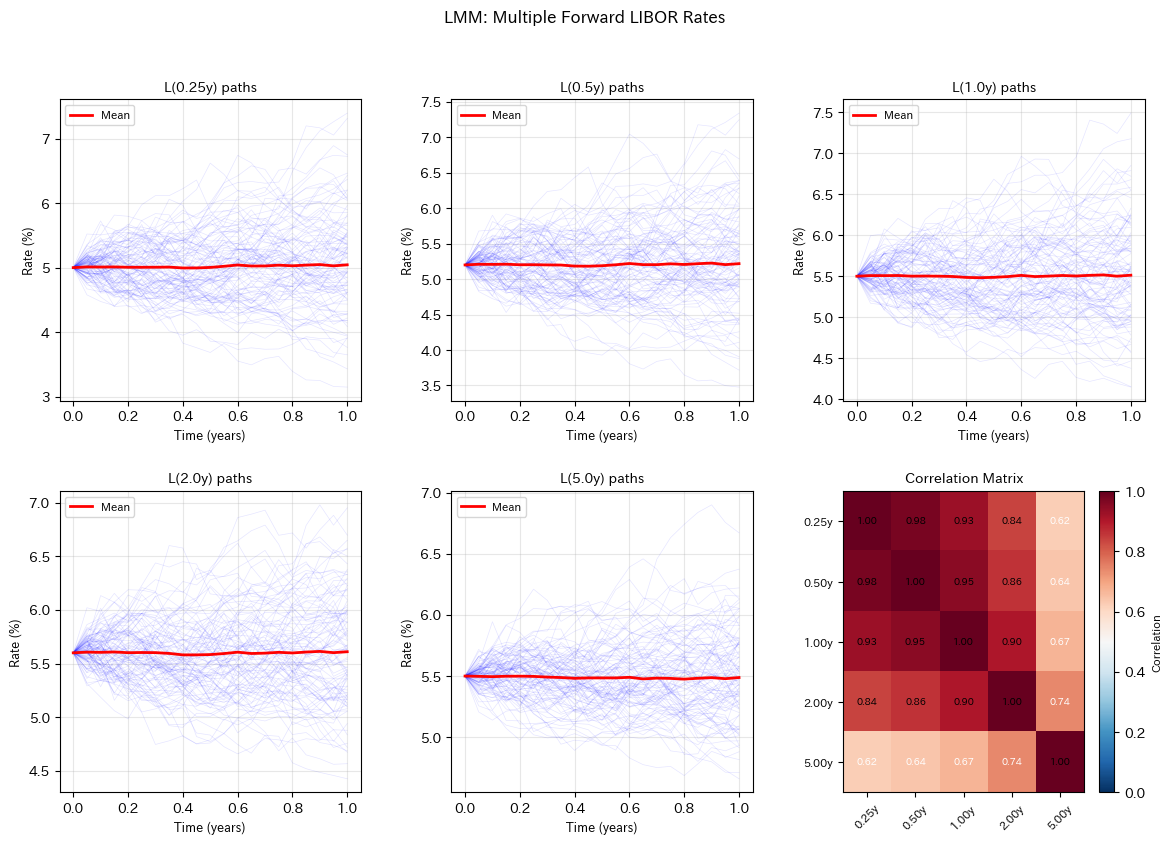

In [54]:

# ===== LMM Forward Rate Paths + Correlation Heatmap =====

def plot_lmm_analysis():
    """
    LMM simulation and correlation visualization
    """
    
    tenors = np.array([0.25, 0.5, 1.0, 2.0, 5.0])
    L_initial = np.array([0.05, 0.052, 0.055, 0.056, 0.055])
    vols = np.array([0.15, 0.14, 0.12, 0.10, 0.08])
    
    n_tenors = len(tenors)
    corr_matrix = np.zeros((n_tenors, n_tenors))
    for i in range(n_tenors):
        for j in range(n_tenors):
            corr_matrix[i, j] = np.exp(-0.1 * abs(tenors[i] - tenors[j]))
    np.fill_diagonal(corr_matrix, 1.0)
    
    L_paths = lmm_forward_libor_simulation(L_initial, tenors, vols, corr_matrix, T=1.0, n_steps=20, n_paths=300)
    time_grid = np.linspace(0, 1.0, L_paths.shape[1])
    
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    fig.suptitle('LMM: Multiple Forward LIBOR Rates', fontsize=12, fontweight='bold')
    
    # Panel 1-5: Forward rate paths for each tenor
    for idx, tenor in enumerate(tenors):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        
        for path_idx in range(min(100, L_paths.shape[0])):
            ax.plot(time_grid, L_paths[path_idx, :, idx] * 100, 'b-', alpha=0.1, linewidth=0.5)
        
        mean_path = np.mean(L_paths[:, :, idx], axis=0)
        ax.plot(time_grid, mean_path * 100, 'r-', linewidth=2, label='Mean')
        ax.set_xlabel('Time (years)', fontsize=9)
        ax.set_ylabel('Rate (%)', fontsize=9)
        ax.set_title(f'L({tenor}y) paths', fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    # Panel 6: Correlation heatmap
    ax = fig.add_subplot(gs[1, 2])
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')
    
    tenor_labels = [f'{t:.2f}y' for t in tenors]
    ax.set_xticks(range(n_tenors))
    ax.set_yticks(range(n_tenors))
    ax.set_xticklabels(tenor_labels, fontsize=8, rotation=45)
    ax.set_yticklabels(tenor_labels, fontsize=8)
    ax.set_title('Correlation Matrix', fontsize=10, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation', fontsize=8)
    
    # Add text annotations
    for i in range(n_tenors):
        for j in range(n_tenors):
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', 
                   fontsize=7, color='black' if abs(corr_matrix[i, j] - 0.5) > 0.3 else 'white')
    
    plt.show()

plot_lmm_analysis()
    


## 主な特徴

### 強み
- ✅ **Market modelとして直感的**
- ✅ Caplet pricing と市場一致
- ✅ テナー毎に独立に volatility 設定可能
- ✅ Correlation 構造を細かく制御

### 弱み
- ❌ Smile/Skew を本来は表現できない（Lognormal前提）
- ❌ 多数のテナー → 高次元で計算負荷
- ❌ LIBOR廃止後の適用に課題

### 使用場面
- 🏦 **Cap/Floor市場との整合性**
- 🏦 複数テナーの同時モデリング
- 🏦 Swaption + Caplet の同時価格付け
    


# Chapter 9: SABR Model (Stochastic Alpha-Beta-Rho)

## 概要

**SABR** は、**Smile/Skew を自然に表現** する重要なモデルです。

金利オプション（Swaption）の市場では、 SABR smile が標準的です。

## 基本式

$$dF_t = \alpha_t F_t^\beta dW_t^{(1)}$$

$$d\alpha_t = \nu \alpha_t dW_t^{(2)}$$

$$dW_t^{(1)} dW_t^{(2)} = \rho dt$$

**パラメータ（4つ）:**
- $\alpha$ = Volatility of volatility (initial)
- $\beta$ = CEV exponent (0=Normal, 1=Lognormal, 0<β<1=Hybrid)
- $\rho$ = Correlation between rate and vol (skew)
- $\nu$ = Vol of vol (smile curvature)
    

In [55]:

def lmm_forward_libor_simulation(L_initial, tenors, vols, corr_matrix, T, n_steps, n_paths=500):
    """
    LMM simulation: Multiple forward LIBORs

    dL_i(t) / L_i(t) = μ_i(t) dt + σ_i(t) dW_t^(i)

    Spot measure drift used in this toy setup:
    μ_j(t) = σ_j * Σ_{k=0}^{j} ρ_{jk} σ_k τ_k L_k / (1 + τ_k L_k)
    """
    n_tenors = len(tenors)
    dt = T / n_steps
    tau = np.diff(np.concatenate(([0], tenors)))

    # Initialize
    L_paths = np.zeros((n_paths, n_steps + 1, n_tenors))
    L_paths[:, 0, :] = L_initial[np.newaxis, :]

    # Cholesky decomposition for correlated Brownians
    L_chol = np.linalg.cholesky(corr_matrix)

    for i in range(1, n_steps + 1):
        dZ = np.random.normal(0, np.sqrt(dt), (n_paths, n_tenors))
        dW = np.dot(dZ, L_chol.T)

        for j in range(n_tenors):
            if vols[j] > 0:
                L_t = L_paths[:, i - 1, j]

                # Spot-measure drift: sum over already-started accrual intervals up to tenor j.
                mu_j = 0.0
                for k in range(0, j + 1):
                    L_k = L_paths[:, i - 1, k]
                    tau_k = tau[k]
                    rho_jk = corr_matrix[j, k]
                    term = rho_jk * vols[k] * tau_k * L_k / (1 + tau_k * L_k)
                    mu_j += term

                mu_j *= vols[j]

                drift_correction = (mu_j - 0.5 * vols[j]**2) * dt
                diffusion = vols[j] * dW[:, j]
                L_paths[:, i, j] = L_t * np.exp(drift_correction + diffusion)
            else:
                L_paths[:, i, j] = L_paths[:, i - 1, j]

    return L_paths

# Test
tenors = np.array([0.25, 0.5, 1.0, 2.0, 5.0])
L_initial = np.array([0.05, 0.052, 0.055, 0.056, 0.055])
vols = np.array([0.15, 0.14, 0.12, 0.10, 0.08])

# Correlation matrix (decreasing with tenor distance)
n_tenors = len(tenors)
corr_matrix = np.zeros((n_tenors, n_tenors))
for i in range(n_tenors):
    for j in range(n_tenors):
        corr_matrix[i, j] = np.exp(-0.1 * abs(tenors[i] - tenors[j]))

np.fill_diagonal(corr_matrix, 1.0)

print("LMM Parameters:")
print(f"Tenors: {tenors}")
print(f"Initial forward rates: {L_initial * 100}")
print(f"Volatilities: {vols * 100}")

# Simulate
L_paths = lmm_forward_libor_simulation(L_initial, tenors, vols, corr_matrix, T=1.0, n_steps=20, n_paths=300)
print(f"\nSimulation output shape: {L_paths.shape}")


LMM Parameters:
Tenors: [0.25 0.5  1.   2.   5.  ]
Initial forward rates: [5.  5.2 5.5 5.6 5.5]
Volatilities: [15. 14. 12. 10.  8.]

Simulation output shape: (300, 21, 5)


In [56]:

def hagan_sabr_formula(F, K, T, alpha, beta, rho, nu):
    """
    Hagan et al. (2002) SABR approximation for Black implied volatility.

    Returns implied Black volatility.
    """
    if F <= 0 or K <= 0 or T <= 0:
        return np.nan

    if abs(F - K) < 1e-10:
        sigma_atm = alpha / (F ** (1 - beta))
        correction = 1 + T * (
            (1 - beta)**2 / 24 * alpha**2 / F**(2 * (1 - beta))
            + rho * beta * nu * alpha / (4 * F**(1 - beta))
            + (2 - 3 * rho**2) / 24 * nu**2
        )
        return sigma_atm * correction

    log_fk = np.log(F / K)
    fk_mid = (F * K) ** ((1 - beta) / 2)
    z = nu / alpha * fk_mid * log_fk
    denom = 1 + (1 - beta)**2 / 24 * log_fk**2 + (1 - beta)**4 / 1920 * log_fk**4
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z**2) + z - rho) / (1 - rho))
    ratio = z / x_z if abs(x_z) > 1e-12 else 1.0
    correction = 1 + T * (
        (1 - beta)**2 / 24 * alpha**2 / (F * K)**(1 - beta)
        + rho * beta * nu * alpha / (4 * fk_mid)
        + (2 - 3 * rho**2) / 24 * nu**2
    )
    return alpha / (fk_mid * denom) * ratio * correction


In [57]:

# ===== SABR Interactive: Smile/Skew 動的可視化 =====

from ipywidgets import FloatSlider, interact

def plot_sabr_smile(alpha_pct, beta_param, rho_param, nu_param):
    """
    SABR parameters を変更してsmile/skewを可視化
    """
    
    F_atm = 0.03
    alpha = alpha_pct / 100 * F_atm
    T = 1.0
    
    strikes = np.linspace(0.01, 0.05, 100)
    impl_vols = np.array([hagan_sabr_formula(F_atm, K, T, alpha, beta_param, rho_param, nu_param) 
                          for K in strikes])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'SABR Smile: α={alpha_pct:.1f}%, β={beta_param:.2f}, ρ={rho_param:.2f}, ν={nu_param:.2f}',
                 fontsize=12, fontweight='bold')
    
    # Panel 1: Implied vol curve
    axes[0].plot(strikes * 100, impl_vols * 100, 'b-', linewidth=2.5, label='SABR Smile')
    axes[0].axvline(F_atm * 100, color='r', linestyle='--', alpha=0.7, linewidth=2, label='ATM')
    axes[0].set_xlabel('Strike (%)', fontsize=10)
    axes[0].set_ylabel('Implied Volatility (%)', fontsize=10)
    axes[0].set_title('Smile / Skew Shape', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Greeks sensitivity (Vega by strike)
    atm_vol = hagan_sabr_formula(F_atm, F_atm, T, alpha, beta_param, rho_param, nu_param)
    
    # Numerical vega
    dv = 0.001
    vegas = []
    for K in strikes:
        vol_up = hagan_sabr_formula(F_atm, K, T, alpha, beta_param, rho_param, nu_param + dv)
        vol_down = hagan_sabr_formula(F_atm, K, T, alpha, beta_param, rho_param, nu_param - dv)
        vega_numeric = (vol_up - vol_down) / (2 * dv)
        vegas.append(vega_numeric)
    
    axes[1].plot(strikes * 100, vegas, 'g-', linewidth=2.5)
    axes[1].axvline(F_atm * 100, color='r', linestyle='--', alpha=0.7, linewidth=2)
    axes[1].set_xlabel('Strike (%)', fontsize=10)
    axes[1].set_ylabel('Vega Smile (d implied vol / d ν)', fontsize=10)
    axes[1].set_title('Vega Sensitivity to Vol-of-Vol', fontsize=11, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

interact(
    plot_sabr_smile,
    alpha_pct=FloatSlider(min=5, max=50, step=2, value=30, description='α (% of F):'),
    beta_param=FloatSlider(min=0, max=1, step=0.1, value=0.5, description='β:'),
    rho_param=FloatSlider(min=-0.9, max=0.9, step=0.1, value=-0.5, description='ρ (skew):'),
    nu_param=FloatSlider(min=0.01, max=2, step=0.1, value=0.5, description='ν (smile):')
)

print("✓ Adjust parameters to see smile/skew change")
    

interactive(children=(FloatSlider(value=30.0, description='α (% of F):', max=50.0, min=5.0, step=2.0), FloatSl…

✓ Adjust parameters to see smile/skew change



## SABR キャリブレーション（市場クォートへのフィット）

実際の市場では、各ストライクの **Implied Vol を観測** し、
SABR パラメータ (α, ρ, ν) を最小二乗でフィットします。
β は通常 0.5 に固定します（market convention）。

$$\min_{\alpha, \rho, \nu} \sum_j \left( \sigma_{SABR}(K_j) - \sigma^{mkt}_j \right)^2$$

詳細な Vol Surface キャリブレーションは **Chapter 11** で扱います。
    

=== SABR Calibration Demo ===
True:   α=0.0140, ρ=-0.450, ν=0.450
Fitted: α=0.0140, ρ=-0.450, ν=0.450
RMSE: 1.43 bp


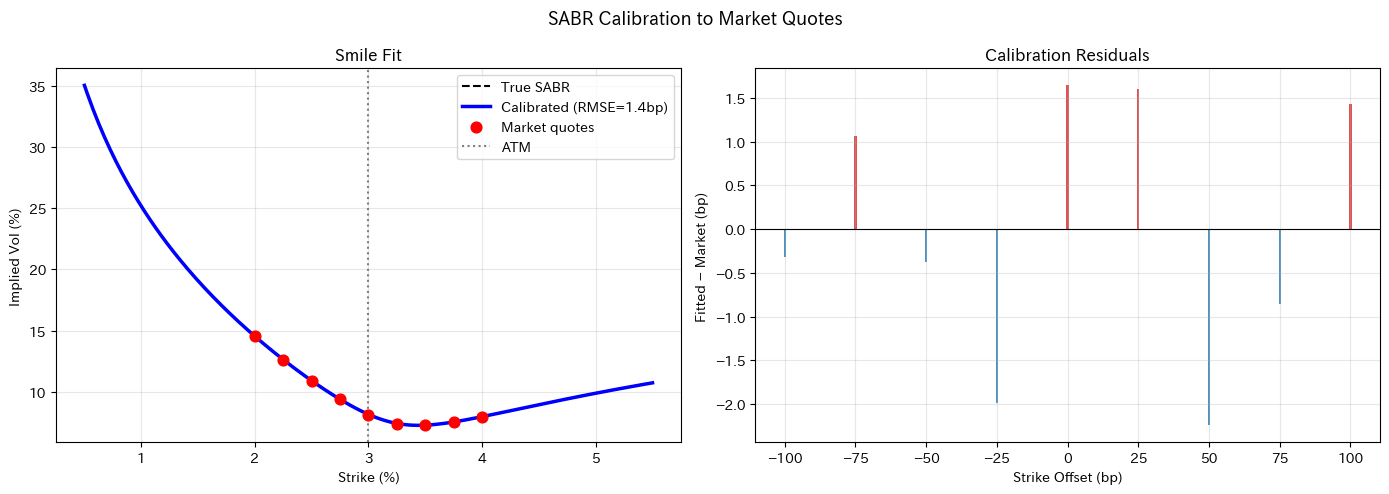

✓ SABR calibration demo complete  →  詳細は Chapter 11 へ


In [58]:

from scipy.optimize import minimize

def calibrate_sabr_ch9(F, T, strikes, market_vols, beta=0.5):
    """Simple SABR calibration for Ch9 demo"""
    alpha0 = market_vols[len(market_vols)//2] * F**(1 - beta)
    bounds = [(1e-4, None), (-0.9999, 0.9999), (1e-4, None)]

    def obj(params):
        a, r, n = params
        model_v = np.array([hagan_sabr_formula(F, K, T, a, beta, r, n) for K in strikes])
        mask = ~np.isnan(model_v)
        return np.sum((model_v[mask] - market_vols[mask])**2) if np.any(mask) else 1e6

    res = minimize(obj, [alpha0, -0.3, 0.4], method='L-BFGS-B', bounds=bounds)
    a_fit, r_fit, n_fit = res.x
    fitted = np.array([hagan_sabr_formula(F, K, T, a_fit, beta, r_fit, n_fit) for K in strikes])
    rmse_bp = np.sqrt(np.mean((fitted - market_vols)**2)) * 10000
    return a_fit, r_fit, n_fit, rmse_bp, fitted

# ===== 疑似市場クォートの生成（True SABR + ノイズ） =====
np.random.seed(42)
F_cal = 0.03
T_cal = 1.0
beta_cal = 0.5
true_alpha, true_rho, true_nu = 0.014, -0.45, 0.45
offsets_bp = np.array([-100, -75, -50, -25, 0, 25, 50, 75, 100])
strikes_cal = np.maximum(F_cal + offsets_bp / 10000, 1e-4)

true_vols = np.array([hagan_sabr_formula(F_cal, K, T_cal, true_alpha, beta_cal, true_rho, true_nu)
                      for K in strikes_cal])
market_vols_cal = true_vols + np.random.normal(0, 2e-4, len(strikes_cal))  # 2bp noise

# ===== キャリブレーション実行 =====
a_fit, r_fit, n_fit, rmse, fitted_v = calibrate_sabr_ch9(
    F_cal, T_cal, strikes_cal, market_vols_cal, beta=beta_cal
)

print("=== SABR Calibration Demo ===")
print(f"True:   α={true_alpha:.4f}, ρ={true_rho:.3f}, ν={true_nu:.3f}")
print(f"Fitted: α={a_fit:.4f}, ρ={r_fit:.3f}, ν={n_fit:.3f}")
print(f"RMSE: {rmse:.2f} bp")

# ===== 可視化 =====
fine_k = np.linspace(0.005, 0.055, 200)
true_fine = np.array([hagan_sabr_formula(F_cal, K, T_cal, true_alpha, beta_cal, true_rho, true_nu)
                      for K in fine_k])
fit_fine = np.array([hagan_sabr_formula(F_cal, K, T_cal, a_fit, beta_cal, r_fit, n_fit)
                     for K in fine_k])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SABR Calibration to Market Quotes', fontsize=13, fontweight='bold')

axes[0].plot(fine_k*100, true_fine*100, 'k--', lw=1.5, label='True SABR')
axes[0].plot(fine_k*100, fit_fine*100, 'b-', lw=2.5, label=f'Calibrated (RMSE={rmse:.1f}bp)')
axes[0].scatter(strikes_cal*100, market_vols_cal*100, color='red', s=60, zorder=5, label='Market quotes')
axes[0].axvline(F_cal*100, color='gray', ls=':', lw=1.5, label='ATM')
axes[0].set_xlabel('Strike (%)'); axes[0].set_ylabel('Implied Vol (%)')
axes[0].set_title('Smile Fit'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals = (fitted_v - market_vols_cal) * 10000
colors = ['#d62728' if e > 0 else '#1f77b4' for e in residuals]
axes[1].bar(offsets_bp, residuals, color=colors, alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Strike Offset (bp)'); axes[1].set_ylabel('Fitted − Market (bp)')
axes[1].set_title('Calibration Residuals'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ SABR calibration demo complete  →  詳細は Chapter 11 へ")
    


## 主な特徴

### 強み
- ✅ **Smile/Skew を自然に表現**
- ✅ 少数パラメータ（4つ）で直感的
- ✅ Hagan公式により高速計算
- ✅ Swaption市場で標準

### 弱み
- ❌ 解析的closed-form解はない（Hagan近似）
- ❌ パラメータキャリブレーションが必要
- ❌ Short maturities では精度低下

### 使用場面
- 🏦 **Swaption smile価格付け**
- 🏦 Exotics（Bermudan等）
- 🏦 **Vol surface calibration** → 詳細は Chapter 11
    


# Chapter 10: RFR Framework

## 概要

**LIBOR廃止**（2023年）に伴い、世界の金利市場は **Reference Rate (RFR)** へ移行しました。

従来のモデルは **固定テナーの LIBOR** を前提としていましたが、  
現在は **日次複利 RFR** をベースにした金利モデリングが必須です。

### 各国のRFR
| 地域 | 旧LIBOR | 新RFR | 特徴 |
|-----|--------|-------|------|
| **米国** | USD LIBOR | SOFR | Treasury Repo Rate（セキュア） |
| **英国** | GBP LIBOR | SONIA | Bank of England政策レート |
| **日本** | JPY LIBOR | TONA | 無担保コール市場 |
| **EU** | EUR LIBOR | ESTR | ECB政策レート |

## RFRの本質

### LIBOR（テナー・アベレージ）
\[
L_i(T_{start}, T_{end}) = \frac{1}{\delta}\left( \frac{P(T_{start})}{P(T_{end})} - 1 \right)
\]
- 将来のテナー期間（3M, 6M等）の平均金利を**前もって決定**
- 市場参加者のサーベイに基づく（LIBOR scandal の原因）

### RFR（日次複利）
\[
R(T_{start}, T_{end}) = \prod_{d=1}^{D}(1 + r_d \delta_d) - 1
\]
- **毎日の** overnight rate を実績ベースで複利
- 透明性が高い（取引ベース）
- **離散複利** → **連続複利**への近似
    

In [59]:

def hagan_sabr_formula(F, K, T, alpha, beta, rho, nu):
    """
    Hagan et al. (2002) SABR approximation for Black implied volatility.

    Returns implied Black volatility.
    """
    if F <= 0 or K <= 0 or T <= 0:
        return np.nan

    if abs(F - K) < 1e-10:
        sigma_atm = alpha / (F ** (1 - beta))
        correction = 1 + T * (
            (1 - beta)**2 / 24 * alpha**2 / F**(2 * (1 - beta))
            + rho * beta * nu * alpha / (4 * F**(1 - beta))
            + (2 - 3 * rho**2) / 24 * nu**2
        )
        return sigma_atm * correction

    log_fk = np.log(F / K)
    fk_mid = (F * K) ** ((1 - beta) / 2)
    z = nu / alpha * fk_mid * log_fk
    denom = 1 + (1 - beta)**2 / 24 * log_fk**2 + (1 - beta)**4 / 1920 * log_fk**4
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z**2) + z - rho) / (1 - rho))
    ratio = z / x_z if abs(x_z) > 1e-12 else 1.0
    correction = 1 + T * (
        (1 - beta)**2 / 24 * alpha**2 / (F * K)**(1 - beta)
        + rho * beta * nu * alpha / (4 * fk_mid)
        + (2 - 3 * rho**2) / 24 * nu**2
    )
    return alpha / (fk_mid * denom) * ratio * correction

# Test
F_atm = 0.03  # 3% forward
strikes = np.linspace(0.01, 0.05, 50)
T = 1.0

# SABR parameters
alpha_param = 0.3 * F_atm  # 30% of forward
beta_param = 0.5  # CEV exponent
rho_param = -0.5  # Negative correlation (downward skew)
nu_param = 0.5  # Vol of vol

impl_vols = np.array([
    hagan_sabr_formula(F_atm, K, T, alpha_param, beta_param, rho_param, nu_param)
    for K in strikes
])

print("SABR Implied Volatility Smile:")
print(f"Parameters: α={alpha_param*100:.2f}%, β={beta_param}, ρ={rho_param}, ν={nu_param}")
print(f"Forward: {F_atm*100:.2f}%, T: {T:.1f}y")
print(f"\nStrike vs Implied Vol:")
for K, iv in zip(strikes[::5], impl_vols[::5]):
    print(f"  K={K*100:.2f}%: σ={iv*100:.3f}%")


SABR Implied Volatility Smile:
Parameters: α=0.90%, β=0.5, ρ=-0.5, ν=0.5
Forward: 3.00%, T: 1.0y

Strike vs Implied Vol:
  K=1.00%: σ=22.529%
  K=1.41%: σ=17.536%
  K=1.82%: σ=13.634%
  K=2.22%: σ=10.350%
  K=2.63%: σ=7.452%
  K=3.04%: σ=5.077%
  K=3.45%: σ=4.864%
  K=3.86%: σ=5.888%
  K=4.27%: σ=6.926%
  K=4.67%: σ=7.859%


In [60]:

# ===== RFR Curve Evolution =====

def plot_rfr_framework(vol_level, curve_slope):
    """
    RFR曲線の進化を可視化
    """
    
    T_array = np.linspace(0.25, 10, 40)  # 3M から 10Y
    
    # RFR discount curve (simpler than LIBOR - single curve)
    base_level = 0.05
    rfr_curve = base_level + curve_slope * (1 - np.exp(-T_array / 5))
    
    # Simulate path of overnight rate
    np.random.seed(42)
    dt = 1 / 252
    n_days = 252
    r_on = np.zeros(n_days)
    r_on[0] = base_level
    for i in range(1, n_days):
        drift = -0.05 * (r_on[i-1] - base_level)
        r_on[i] = r_on[i-1] + drift * dt + vol_level * np.random.randn() * np.sqrt(dt)
        r_on[i] = max(r_on[i], 0)
    
    # Discount curve
    df_rfr = np.exp(-rfr_curve * T_array)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'RFR Framework: Overnight Vol={vol_level:.3f}, Curve Slope={curve_slope:.2%}',
                 fontsize=12, fontweight='bold')
    
    # Panel 1: RFR Zero Curve
    axes[0].plot(T_array, rfr_curve * 100, 'g-', linewidth=2.5, marker='o', markersize=4)
    axes[0].fill_between(T_array, 0, rfr_curve * 100, alpha=0.2, color='green')
    axes[0].set_xlabel('Maturity (years)', fontsize=10)
    axes[0].set_ylabel('Zero Rate (%)', fontsize=10)
    axes[0].set_title('RFR Zero Curve (Single Curve)', fontsize=11, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Overnight Rate Path
    days = np.arange(n_days)
    axes[1].plot(days, r_on * 100, 'b-', linewidth=1, alpha=0.7)
    axes[1].axhline(y=np.mean(r_on)*100, color='r', linestyle='--', linewidth=2, label=f'Mean={np.mean(r_on)*100:.2f}%')
    axes[1].fill_between(days, 0, r_on * 100, alpha=0.2, color='blue')
    axes[1].set_xlabel('Days', fontsize=10)
    axes[1].set_ylabel('Overnight Rate (%)', fontsize=10)
    axes[1].set_title('Daily ON Rate (1Y simulation)', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: Discount Factors
    axes[2].plot(T_array, df_rfr, 'g-', linewidth=2.5, marker='o', markersize=4)
    axes[2].set_xlabel('Maturity (years)', fontsize=10)
    axes[2].set_ylabel('Discount Factor', fontsize=10)
    axes[2].set_title('RFR Discount Factors', fontsize=11, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

from ipywidgets import FloatSlider, interact

interact(
    plot_rfr_framework,
    vol_level=FloatSlider(min=0.0005, max=0.01, step=0.0005, value=0.002, description='ON Vol:'),
    curve_slope=FloatSlider(min=0, max=0.05, step=0.005, value=0.02, description='Curve Slope:')
)
    

interactive(children=(FloatSlider(value=0.002, description='ON Vol:', max=0.01, min=0.0005, step=0.0005), Floa…

<function __main__.plot_rfr_framework(vol_level, curve_slope)>


## RFR vs LIBOR in モデリング

### Single Curve vs Multi-Curve

**LIBOR時代（2020年以前）:**
- Forward LIBOR と Discounting が一つのcurveで混在
- Basis spread は副次的（低）

**RFR時代（2023年以降）:**
- **単一RFR曲線**でDiscounting & Forward rateを統一
- LIBOR legacy商品とRFR新商品を区別管理

### 金利モデルへの影響

| 項目 | LIBOR | RFR |
|------|-------|-----|
| **State Variable** | Tenor-based forward rate | Overnight rate + 複利演算 |
| **Curve数** | Multi-curve（OIS+LIBOR）| Single curve |
| **Compounding** | 単一テナー | 日次複利 |
| **モデル** | LMM/BGM | RFR-based LMM |
| **Smile** | High（LIBOR basis） | Low（単純化） |

## 主な特徴

### 強み
- ✅ **単一曲線で完結**（シンプル）
- ✅ 透明性・統一性が高い
- ✅ ベンチマーク金利として信頼性
- ✅ Global移行の標準

### 弱み
- ❌ Legacy LIBOR商品との管理複雑化
- ❌ Transition期間（2020-2023）でのconvexity
- ❌ RFR basis（テナー別RFRは存在しない）

### 使用場面
- 🏦 **現在のすべての新規取引**
- 🏦 金利デリバティブ（IRS, Caps, Swaptions）
- 🏦 融資・貸出金利ベンチマーク
- 🏦 Legacy LIBOR商品のヘッジ・管理
    


# Final Chapter: Model Comparison & Selection Guide

これまでの10のモデルを、横断的に比較します。

- モデル分類
- 機能比較
- 使用場面
- パラメータ数
- 計算複雑度
    

In [61]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Model Comparison Table =====

models_data = {
    'Model': ['Black 76', 'Bachelier', 'Vasicek', 'CIR', 'Hull-White 1F', 'G2++', 'HJM', 'LMM/BGM', 'SABR', 'Multi-Curve'],
    'Type': ['Option', 'Option', 'SRM', 'SRM', 'SRM', 'SRM', 'Framework', 'Market', 'Option', 'Framework'],
    'Factors': [0, 0, 1, 1, 1, 2, 'Multi', 'Multi', 2, 'Multi'],
    'Neg Rates': ['No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Hybrid', 'Flexible'],
    'Smile': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes'],
    'Curve Fit': ['N/A', 'N/A', 'Manual', 'Manual', 'Auto', 'Auto', 'Auto', 'Auto', 'Manual', 'Auto'],
    'Greeks': ['Analytical', 'Analytical', 'Analytical', 'Numerical', 'Analytical', 'Numerical', 'Numerical', 'Numerical', 'Hagan', 'Numerical'],
    'Complexity': [1, 1, 2, 2, 3, 4, 5, 5, 3, 5],
    'Industry Use': [10, 3, 4, 3, 10, 8, 2, 9, 9, 10]
}

df_comparison = pd.DataFrame(models_data)

print("="*100)
print("MODEL COMPARISON TABLE")
print("="*100)
print(df_comparison.to_string(index=False))
print("\nLegend:")
print("  Type: Option=Option pricing model, SRM=Short Rate Model, Market=Market model, Framework=General framework")
print("  Neg Rates: Support for negative rates")
print("  Smile: Can express smile/skew")
print("  Curve Fit: Auto=Automatic initial curve fit, Manual=Requires manual tuning, N/A=Not applicable")
print("  Greeks: Analytical/Numerical/Hagan approximation")
print("  Complexity: 1(Simple) to 5(Complex)")
print("  Industry Use: 1(Academic) to 10(Standard in practice)")
    

MODEL COMPARISON TABLE
        Model      Type Factors Neg Rates Smile Curve Fit     Greeks  Complexity  Industry Use
     Black 76    Option       0        No    No       N/A Analytical           1            10
    Bachelier    Option       0       Yes    No       N/A Analytical           1             3
      Vasicek       SRM       1       Yes    No    Manual Analytical           2             4
          CIR       SRM       1        No    No    Manual  Numerical           2             3
Hull-White 1F       SRM       1       Yes    No      Auto Analytical           3            10
         G2++       SRM       2       Yes    No      Auto  Numerical           4             8
          HJM Framework   Multi       Yes    No      Auto  Numerical           5             2
      LMM/BGM    Market   Multi       Yes    No      Auto  Numerical           5             9
         SABR    Option       2    Hybrid   Yes    Manual      Hagan           3             9
  Multi-Curve Framework   M

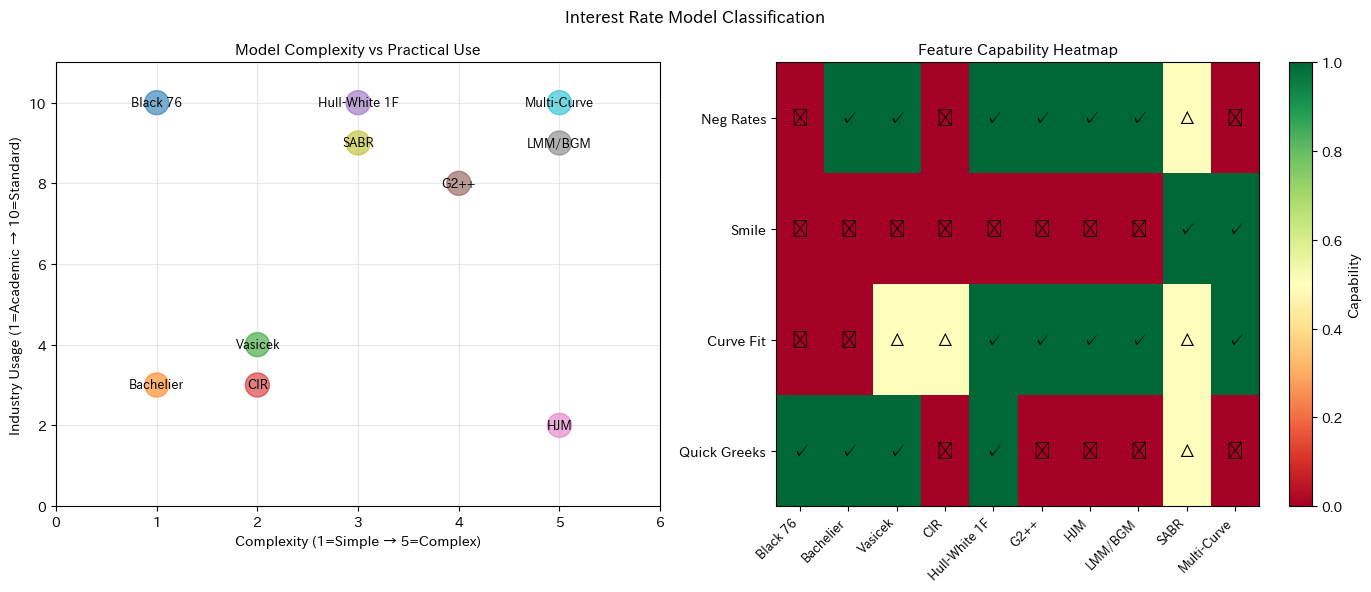

✓ Model classification visualization complete


In [62]:

# ===== Model Classification Scatter =====

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Interest Rate Model Classification', fontsize=12, fontweight='bold')

# Panel 1: Complexity vs Flexibility
models = df_comparison['Model'].values
complexity = df_comparison['Complexity'].values
industry_use = df_comparison['Industry Use'].values

scatter = axes[0].scatter(complexity, industry_use, s=300, alpha=0.6, c=range(len(models)), cmap='tab10')

for i, model in enumerate(models):
    axes[0].annotate(model, (complexity[i], industry_use[i]), 
                    fontsize=9, ha='center', va='center', fontweight='bold')

axes[0].set_xlabel('Complexity (1=Simple → 5=Complex)', fontsize=10)
axes[0].set_ylabel('Industry Usage (1=Academic → 10=Standard)', fontsize=10)
axes[0].set_title('Model Complexity vs Practical Use', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 6)
axes[0].set_ylim(0, 11)

# Panel 2: Feature Capability Matrix
features = ['Neg Rates', 'Smile', 'Curve Fit', 'Quick Greeks']
capability_matrix = np.zeros((len(models), len(features)))

for i, model in enumerate(models):
    capability_matrix[i, 0] = 1 if df_comparison.loc[i, 'Neg Rates'] == 'Yes' else 0.5 if df_comparison.loc[i, 'Neg Rates'] == 'Hybrid' else 0
    capability_matrix[i, 1] = 1 if df_comparison.loc[i, 'Smile'] == 'Yes' else 0
    capability_matrix[i, 2] = 1 if df_comparison.loc[i, 'Curve Fit'] == 'Auto' else 0.5 if df_comparison.loc[i, 'Curve Fit'] == 'Manual' else 0
    capability_matrix[i, 3] = 1 if df_comparison.loc[i, 'Greeks'] == 'Analytical' else 0.5 if df_comparison.loc[i, 'Greeks'] == 'Hagan' else 0

im = axes[1].imshow(capability_matrix.T, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

axes[1].set_xticks(range(len(models)))
axes[1].set_yticks(range(len(features)))
axes[1].set_xticklabels(models, fontsize=9, rotation=45, ha='right')
axes[1].set_yticklabels(features, fontsize=10)
axes[1].set_title('Feature Capability Heatmap', fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=axes[1], label='Capability')

# Add text annotations
for i in range(len(models)):
    for j in range(len(features)):
        val = capability_matrix[i, j]
        text = '✓' if val == 1 else '△' if val == 0.5 else '✗'
        axes[1].text(i, j, text, ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Model classification visualization complete")
    


## 使用場面別ガイド

### Caplet / Cap-Floor
- ✅ **Black 76** (市場標準)
- ✅ **Bachelier** (マイナス金利環境)
- ✅ **LMM/BGM** (複数テナー同時)

### Swaption
- ✅ **Hull-White 1F** (シンプル)
- ✅ **G2++** (スロープ変動)
- ✅ **SABR** (Smile対応、市場標準)

### Bermudan Swaption
- ✅ **G2++** (2ファクター)
- ✅ **LMM/BGM** (多ファクター)

### 初期学習・教育
- ✅ **Vasicek** (基本)
- ✅ **Black 76 & Bachelier** (オプション基礎)
- ✅ **Hull-White 1F** (実務基本)

### 学術研究
- ✅ **HJM Framework** (理論的枠組み)
- ✅ **CIR** (非負性の数学)
- ✅ **SABR** (Smile理論)

### 現代的な金利管理
- ✅ **Multi-Curve Framework** (必須)
- ✅ **RFR Models** (SOFR/SONIA対応)
    


## まとめ

### 金利モデル選択の視点

| 観点 | チェックポイント |
|------|-----------------|
| **市場データ** | Caplet? Swaption? Bermudan? 複数テナー? |
| **金利環境** | マイナス金利の可能性？ |
| **計算速度** | Real-time pricing 必要？ |
| **精度** | Smile/Skew を表現すべき？ |
| **実装コスト** | 開発リソース？ |
| **市場標準** | Industry convention への準拠 |

---

## 次のステップ

このノートブックで学習した内容：

1. ✅ 金利の基本概念（Yield curve, Forward rate）
2. ✅ オプション価格付けの基本（Black-Scholes → Black 76, Bachelier）
3. ✅ 短期金利モデル（Vasicek, CIR, Hull-White）
4. ✅ マルチファクターモデル（G2++）
5. ✅ 統一的枠組み（HJM）
6. ✅ マーケットモデル（LMM/BGM）
7. ✅ Smile表現（SABR）
8. ✅ 現代的枠組み（Multi-Curve, RFR）

### 実務への適用
- キャリブレーションの実装
- 価格付けエンジンの構築
- Greeks の計算
- ストレステスト・シナリオ分析

### さらに深堀りするテーマ
- Volatility surface interpolation
- Cross-gamma / Correlation risk
- XVA (CVA, DVA, KVA)
- Machine learning for calibration
    


# Chapter 11: Volatility Smile / Skew — 分析とキャリブレーション

## 概要

**Volatility Smile/Skew** とは、同一満期・同一原資産でもストライクによって
Implied Volatility が異なる現象です。

BS/Black76 は定数ボラティリティを仮定しているため、市場では必ず smile/skew が観測されます。

### 本章の構成

| Section | 内容 |
|---------|------|
| 11.1 | Implied Volatility の逆算（Black76 / Bachelier inverse） |
| 11.2 | サンプル市場データ：合成 Vol Surface の生成 |
| 11.3 | SABR 単一スマイルキャリブレーション |
| 11.4 | SABR Vol Surface キャリブレーション（全テナー） |
| 11.5 | SVI パラメタリゼーション（代替スマイルモデル） |
| 11.6 | Smile/Skew メトリクス（ATM・RR・BF） |
| 11.7 | 3D Vol Surface 可視化 |

---

## 市場で見られる主な形状

- **Smile** : ATM から両端に向かって vol が上昇（ジャンプリスク）
- **Skew** : 片側だけ上昇（OTM プット > OTM コール）— 金利市場ではダウンスキューが一般的
- **Smirk** : smile + skew の組み合わせ
    


## 11.1 Implied Volatility の逆算

オプション価格（市場クォート）から Implied Vol を求める逆問題です。

### Black76 逆算

$$C_{B76}(F, K, T, \sigma) = \text{観測価格}$$

$\sigma$ について数値的に解く（closed form は存在しない）。

**手法**: `scipy.optimize.brentq` で単調関数の根を求める。

### Bachelier 逆算

$$C_{Bachelier}(F, K, T, \sigma_N) = (F-K)\Phi(d) + \sigma_N\sqrt{T}\phi(d)$$

同様に数値逆算。マイナス金利環境では Bachelier が標準。
    

In [63]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ===== Black76 価格計算 =====
def black76_call(F, K, T, sigma, df=1.0):
    """Black76 call option price"""
    if sigma <= 0 or T <= 0 or F <= 0 or K <= 0:
        return df * max(F - K, 0.0)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return df * (F * norm.cdf(d1) - K * norm.cdf(d2))

def black76_put(F, K, T, sigma, df=1.0):
    """Black76 put option price (put-call parity)"""
    return black76_call(F, K, T, sigma, df) - df * (F - K)

# ===== Bachelier 価格計算 =====
def bachelier_call(F, K, T, sigma_n, df=1.0):
    """Bachelier (normal) call option price"""
    if sigma_n <= 0 or T <= 0:
        return df * max(F - K, 0.0)
    d = (F - K) / (sigma_n * np.sqrt(T))
    return df * ((F - K) * norm.cdf(d) + sigma_n * np.sqrt(T) * norm.pdf(d))

def bachelier_put(F, K, T, sigma_n, df=1.0):
    """Bachelier put option price"""
    return bachelier_call(F, K, T, sigma_n, df) - df * (F - K)

# ===== Black76 Implied Vol 逆算 =====
def black76_implied_vol(price, F, K, T, df=1.0, option_type='call', tol=1e-8):
    """
    Brentq で Black76 implied vol を逆算。
    Returns nan if no solution in [1e-6, 20.0].
    """
    intrinsic = df * max(F - K, 0.0) if option_type == 'call' else df * max(K - F, 0.0)
    if price <= intrinsic + 1e-12:
        return np.nan

    fn = (black76_call if option_type == 'call' else black76_put)
    obj = lambda s: fn(F, K, T, s, df) - price
    try:
        return brentq(obj, 1e-6, 20.0, xtol=tol)
    except ValueError:
        return np.nan

# ===== Bachelier Implied Vol 逆算 =====
def bachelier_implied_vol(price, F, K, T, df=1.0, option_type='call', tol=1e-8):
    """
    Brentq で Bachelier implied vol を逆算。
    Returns nan if no solution.
    """
    intrinsic = df * max(F - K, 0.0) if option_type == 'call' else df * max(K - F, 0.0)
    if price <= intrinsic + 1e-12:
        return np.nan

    fn = (bachelier_call if option_type == 'call' else bachelier_put)
    obj = lambda s: fn(F, K, T, s, df) - price
    try:
        return brentq(obj, 1e-8, 5.0, xtol=tol)
    except ValueError:
        return np.nan

# ===== 検証: ラウンドトリップ精度 =====
print("=== Implied Vol Round-Trip Test ===")
print(f"{'Strike':>8} {'True σ':>10} {'B76 inv σ':>12} {'Error (bp)':>12} {'Bac inv σN':>12} {'Error (bp)':>12}")
print("-" * 70)

F = 0.03
T = 1.0
sigma_true = 0.30  # 30% lognormal vol
sigma_n_true = F * sigma_true  # ≈ normal vol

strikes_test = [0.010, 0.015, 0.020, 0.025, 0.030, 0.035, 0.040, 0.045, 0.050]
b76_errors, bac_errors = [], []

for K in strikes_test:
    price_b76 = black76_call(F, K, T, sigma_true)
    price_bac = bachelier_call(F, K, T, sigma_n_true)

    iv_b76 = black76_implied_vol(price_b76, F, K, T)
    iv_bac = bachelier_implied_vol(price_bac, F, K, T)

    err_b76 = (iv_b76 - sigma_true) * 10000 if not np.isnan(iv_b76) else np.nan
    err_bac = (iv_bac - sigma_n_true) * 10000 if not np.isnan(iv_bac) else np.nan
    b76_errors.append(abs(err_b76))
    bac_errors.append(abs(err_bac))
    print(f"  K={K*100:.1f}%  σ={sigma_true*100:.1f}%  {iv_b76*100:.6f}%  {err_b76:+.4f}bp"
          f"  {iv_bac*100:.6f}%  {err_bac:+.4f}bp")

print(f"\nMax B76 error: {max(b76_errors):.4e} bp | Max Bachelier error: {max(bac_errors):.4e} bp")
print("✓ Round-trip precision verified")
    

=== Implied Vol Round-Trip Test ===
  Strike     True σ    B76 inv σ   Error (bp)   Bac inv σN   Error (bp)
----------------------------------------------------------------------
  K=1.0%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  -0.0000bp
  K=1.5%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  -0.0000bp
  K=2.0%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  +0.0000bp
  K=2.5%  σ=30.0%  30.000000%  +0.0000bp  0.900000%  +0.0000bp
  K=3.0%  σ=30.0%  30.000000%  +0.0000bp  0.900000%  +0.0000bp
  K=3.5%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  +0.0000bp
  K=4.0%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  +0.0000bp
  K=4.5%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  -0.0000bp
  K=5.0%  σ=30.0%  30.000000%  -0.0000bp  0.900000%  -0.0000bp

Max B76 error: 1.6917e-06 bp | Max Bachelier error: 4.9018e-07 bp
✓ Round-trip precision verified



## 11.2 サンプル市場データ：合成 Swaption Vol Surface

**現実的な Swaption Vol Surface** を SABR で生成し、観測ノイズを加えます。

### Surface の次元

- **Expiry（オプション満期）**: 1M, 3M, 6M, 1Y, 2Y, 5Y, 10Y
- **Strike オフセット**: ATM −100bp 〜 ATM +100bp
- **原資産**: 各 Expiry の ATM Forward スワップレート

### 市場の典型的なパラメータ

| Expiry | α   | ρ    | ν   | 特徴 |
|--------|-----|------|-----|------|
| 短期   | 高  | 大負 | 低  | 急峻なスキュー |
| 長期   | 低  | 小負 | 高  | より対称なスマイル |
    

In [64]:

# ===== SABR 公式（Hagan et al. 2002 近似） =====
def hagan_sabr_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan et al. (2002) SABR approximation for Black implied vol"""
    if F <= 0 or K <= 0 or T <= 0:
        return np.nan

    if abs(F - K) < 1e-10:
        sigma_atm = alpha / (F ** (1 - beta))
        correction = 1 + T * (
            (1 - beta)**2 / 24 * alpha**2 / F**(2 * (1 - beta))
            + rho * beta * nu * alpha / (4 * F**(1 - beta))
            + (2 - 3 * rho**2) / 24 * nu**2
        )
        return sigma_atm * correction

    log_fk = np.log(F / K)
    fk_mid = (F * K) ** ((1 - beta) / 2)
    z = nu / alpha * fk_mid * log_fk
    denom = 1 + (1 - beta)**2 / 24 * log_fk**2 + (1 - beta)**4 / 1920 * log_fk**4
    x_z = np.log((np.sqrt(1 - 2 * rho * z + z**2) + z - rho) / (1 - rho))
    ratio = z / x_z if abs(x_z) > 1e-12 else 1.0
    correction = 1 + T * (
        (1 - beta)**2 / 24 * alpha**2 / (F * K)**(1 - beta)
        + rho * beta * nu * alpha / (4 * fk_mid)
        + (2 - 3 * rho**2) / 24 * nu**2
    )
    return alpha / (fk_mid * denom) * ratio * correction

# ===== 合成マーケットデータの設定 =====
# Expiry ごとの ATM forward スワップレート（仮定）
EXPIRIES = np.array([1/12, 3/12, 6/12, 1.0, 2.0, 5.0, 10.0])
EXPIRY_LABELS = ['1M', '3M', '6M', '1Y', '2Y', '5Y', '10Y']

ATM_FORWARDS = np.array([0.028, 0.029, 0.030, 0.031, 0.032, 0.033, 0.034])

# 市場の典型的な SABR パラメータ（Expiry 依存）
# beta は全テナーで 0.5 に固定（実務的な選択）
BETA = 0.5

MARKET_ALPHA = np.array([0.020, 0.018, 0.016, 0.014, 0.012, 0.010, 0.009])
MARKET_RHO   = np.array([-0.60, -0.55, -0.50, -0.45, -0.40, -0.35, -0.30])
MARKET_NU    = np.array([0.30,  0.35,  0.40,  0.45,  0.50,  0.55,  0.60])

# ストライクオフセット (bp)
STRIKE_OFFSETS_BP = np.array([-100, -75, -50, -25, 0, 25, 50, 75, 100])

# ===== Vol Surface 生成 =====
def generate_market_surface(noise_bp=2.0, seed=42):
    """
    SABR で true surface を生成し、市場ノイズを加えた「観測」データを返す。
    戻り値: true_surface, observed_surface — shape (n_expiry, n_strike)
    """
    rng = np.random.default_rng(seed)
    n_exp = len(EXPIRIES)
    n_str = len(STRIKE_OFFSETS_BP)
    true_surface = np.zeros((n_exp, n_str))
    for i, (T, F) in enumerate(zip(EXPIRIES, ATM_FORWARDS)):
        for j, offset_bp in enumerate(STRIKE_OFFSETS_BP):
            K = F + offset_bp / 10000
            K = max(K, 1e-4)
            true_surface[i, j] = hagan_sabr_vol(
                F, K, T,
                MARKET_ALPHA[i], BETA, MARKET_RHO[i], MARKET_NU[i]
            )
    noise = rng.normal(0, noise_bp / 10000, true_surface.shape)
    observed_surface = true_surface + noise
    return true_surface, observed_surface

true_surface, observed_surface = generate_market_surface(noise_bp=2.0)

# ===== サマリー表示 =====
print("=== Synthetic Market Vol Surface (Black lognormal, %) ===")
header = f"{'Expiry':>6}" + "".join(f"  {bp:+d}bp" for bp in STRIKE_OFFSETS_BP)
print(header)
print("-" * len(header))
for i, label in enumerate(EXPIRY_LABELS):
    row = f"{label:>6}" + "".join(f"  {v*100:5.2f}" for v in observed_surface[i])
    print(row)
print("\n✓ Synthetic vol surface generated (SABR true + 2bp noise)")


=== Synthetic Market Vol Surface (Black lognormal, %) ===
Expiry  -100bp  -75bp  -50bp  -25bp  +0bp  +25bp  +50bp  +75bp  +100bp
----------------------------------------------------------------------
    1M  17.73  15.96  14.47  13.14  11.91  10.96  10.23   9.70   9.40
    3M  16.45  14.72  13.15  11.75  10.60   9.67   9.02   8.75   8.67
    6M  15.28  13.47  11.86  10.43   9.29   8.42   8.01   7.98   8.20
    1Y  14.15  12.33  10.68   9.26   8.02   7.30   7.15   7.43   7.86
    2Y  13.18  11.31   9.61   8.11   6.91   6.36   6.50   7.02   7.61
    5Y  12.77  10.82   8.98   7.33   6.04   5.70   6.21   6.93   7.72
   10Y  13.81  11.58   9.49   7.59   6.08   5.98   6.76   7.80   8.79

✓ Synthetic vol surface generated (SABR true + 2bp noise)



## 11.3 SABR 単一スマイルキャリブレーション

1 つの Expiry の市場クォートに SABR パラメータ (α, ρ, ν) をフィットします。
β は事前に固定（実務慣行）。

### 目的関数

$$\min_{\alpha, \rho, \nu} \sum_j \left( \sigma_{SABR}(K_j; \alpha, \rho, \nu) - \sigma^{mkt}_j \right)^2$$

### 制約条件

$$\alpha > 0,\quad -1 < \rho < 1,\quad \nu > 0$$
    

=== SABR Calibration: 1Y Expiry ===
True params : α=0.0140, ρ=-0.450, ν=0.450
Fitted      : α=0.0140, ρ=-0.450, ν=0.451
RMSE        : 1.63 bp

    Strike   Market Vol   Fitted Vol   Error (bp)
--------------------------------------------------
   -100bp   14.1495%   14.1603%    +1.080bp
    -75bp   12.3292%   12.3342%    +0.503bp
    -50bp   10.6811%   10.6811%    +0.005bp
    -25bp    9.2550%    9.2165%    -3.850bp
     +0bp    8.0213%    8.0303%    +0.905bp
    +25bp    7.3026%    7.3131%    +1.050bp
    +50bp    7.1518%    7.1710%    +1.915bp
    +75bp    7.4285%    7.4226%    -0.591bp
   +100bp    7.8574%    7.8443%    -1.305bp


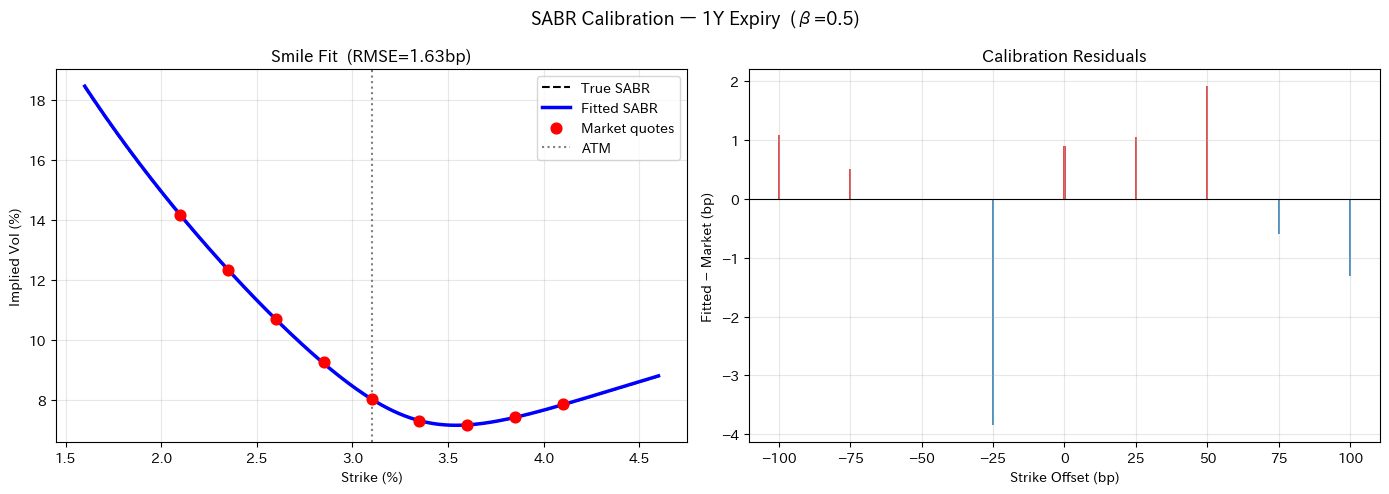

✓ Single smile calibration complete


In [65]:

# ===== SABR キャリブレーション（単一スマイル） =====
def calibrate_sabr_smile(F, T, strikes, market_vols, beta=0.5,
                          alpha0=None, rho0=-0.3, nu0=0.4):
    """
    scipy.optimize.minimize で SABR (alpha, rho, nu) をキャリブレーション。
    beta は固定。
    Returns: (alpha, rho, nu), rmse_bp
    """
    if alpha0 is None:
        alpha0 = market_vols[len(market_vols)//2] * F**(1 - beta)

    bounds = [(1e-4, None), (-0.9999, 0.9999), (1e-4, None)]

    def objective(params):
        a, r, n = params
        model_vols = np.array([hagan_sabr_vol(F, K, T, a, beta, r, n) for K in strikes])
        mask = ~np.isnan(model_vols)
        if not np.any(mask):
            return 1e6
        return np.sum((model_vols[mask] - market_vols[mask])**2)

    result = minimize(objective, [alpha0, rho0, nu0], method='L-BFGS-B', bounds=bounds)
    alpha_fit, rho_fit, nu_fit = result.x

    model_vols_fit = np.array([hagan_sabr_vol(F, K, T, alpha_fit, beta, rho_fit, nu_fit)
                                for K in strikes])
    rmse = np.sqrt(np.mean((model_vols_fit - market_vols)**2)) * 10000  # bp

    return (alpha_fit, rho_fit, nu_fit), rmse, model_vols_fit

# ===== デモ: Expiry = 1Y のスマイルにキャリブレーション =====
EXP_IDX = 3  # 1Y
T_demo = EXPIRIES[EXP_IDX]
F_demo = ATM_FORWARDS[EXP_IDX]
strikes_demo = np.array([F_demo + bp/10000 for bp in STRIKE_OFFSETS_BP])
strikes_demo = np.maximum(strikes_demo, 1e-4)
mkt_vols_demo = observed_surface[EXP_IDX]

(alpha_fit, rho_fit, nu_fit), rmse_demo, fitted_vols = calibrate_sabr_smile(
    F_demo, T_demo, strikes_demo, mkt_vols_demo, beta=BETA
)

print(f"=== SABR Calibration: {EXPIRY_LABELS[EXP_IDX]} Expiry ===")
print(f"True params : α={MARKET_ALPHA[EXP_IDX]:.4f}, ρ={MARKET_RHO[EXP_IDX]:.3f}, ν={MARKET_NU[EXP_IDX]:.3f}")
print(f"Fitted      : α={alpha_fit:.4f}, ρ={rho_fit:.3f}, ν={nu_fit:.3f}")
print(f"RMSE        : {rmse_demo:.2f} bp")
print()
print(f"{'Strike':>10} {'Market Vol':>12} {'Fitted Vol':>12} {'Error (bp)':>12}")
print("-" * 50)
for K, mv, fv in zip(strikes_demo, mkt_vols_demo, fitted_vols):
    offset = (K - F_demo) * 10000
    print(f"  {offset:+5.0f}bp  {mv*100:8.4f}%  {fv*100:8.4f}%  {(fv-mv)*10000:+8.3f}bp")

# ===== 可視化 =====
fine_strikes = np.linspace(max(0.005, F_demo - 0.015), F_demo + 0.015, 200)
fine_true = np.array([hagan_sabr_vol(F_demo, K, T_demo,
                      MARKET_ALPHA[EXP_IDX], BETA, MARKET_RHO[EXP_IDX], MARKET_NU[EXP_IDX])
                      for K in fine_strikes])
fine_fitted = np.array([hagan_sabr_vol(F_demo, K, T_demo, alpha_fit, BETA, rho_fit, nu_fit)
                        for K in fine_strikes])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'SABR Calibration — {EXPIRY_LABELS[EXP_IDX]} Expiry  (β={BETA})', fontsize=13, fontweight='bold')

axes[0].plot(fine_strikes*100, fine_true*100, 'k--', lw=1.5, label='True SABR')
axes[0].plot(fine_strikes*100, fine_fitted*100, 'b-', lw=2.5, label='Fitted SABR')
axes[0].scatter(strikes_demo*100, mkt_vols_demo*100, color='red', zorder=5, s=60, label='Market quotes')
axes[0].axvline(F_demo*100, color='gray', ls=':', lw=1.5, label='ATM')
axes[0].set_xlabel('Strike (%)')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].set_title(f'Smile Fit  (RMSE={rmse_demo:.2f}bp)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors_bp = (fitted_vols - mkt_vols_demo) * 10000
bar_colors = ['#d62728' if e > 0 else '#1f77b4' for e in errors_bp]
axes[1].bar(STRIKE_OFFSETS_BP, errors_bp, color=bar_colors, alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Strike Offset (bp)')
axes[1].set_ylabel('Fitted − Market (bp)')
axes[1].set_title('Calibration Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Single smile calibration complete")
    


## 11.4 SABR Vol Surface キャリブレーション（全 Expiry）

各 Expiry について独立に SABR キャリブレーションを実行し、
キャリブレーション結果を並べて **Vol Surface** を再構築します。

**実務では**:
- β を全テナーで共通固定（例：0.5）
- α, ρ, ν を各テナーで個別にキャリブレーション
- ρ, ν の Expiry 依存性から**市場構造**を読む
    

=== SABR Surface Calibration (β=0.5 fixed) ===
Expiry   α_true    α_fit   ρ_true    ρ_fit   ν_true    ν_fit   RMSE(bp)
---------------------------------------------------------------------------
    1M   0.0200   0.0200   -0.600   -0.598    0.300    0.302      1.734
    3M   0.0180   0.0180   -0.550   -0.554    0.350    0.348      1.199
    6M   0.0160   0.0160   -0.500   -0.500    0.400    0.401      1.164
    1Y   0.0140   0.0140   -0.450   -0.450    0.450    0.451      1.629
    2Y   0.0120   0.0120   -0.400   -0.400    0.500    0.498      1.005
    5Y   0.0100   0.0100   -0.350   -0.352    0.550    0.549      1.024
   10Y   0.0090   0.0090   -0.300   -0.301    0.600    0.599      1.741

Overall Surface RMSE: 1.391 bp
✓ Surface calibration complete


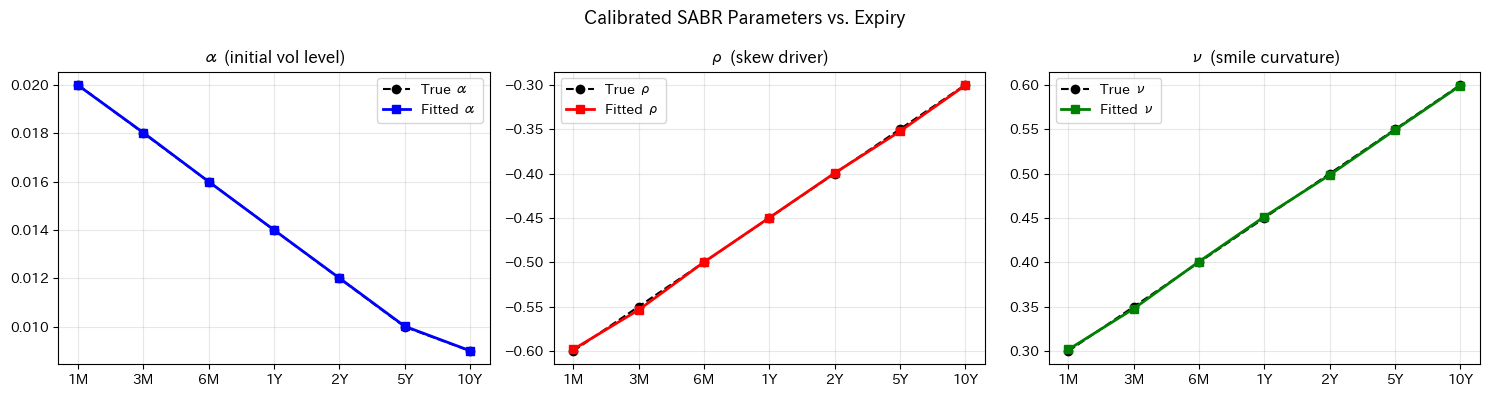

In [66]:

# ===== SABR Surface キャリブレーション =====
print("=== SABR Surface Calibration (β=0.5 fixed) ===")
print(f"{'Expiry':>6} {'α_true':>8} {'α_fit':>8} {'ρ_true':>8} {'ρ_fit':>8} "
      f"{'ν_true':>8} {'ν_fit':>8} {'RMSE(bp)':>10}")
print("-" * 75)

surface_params = []
fitted_surface = np.zeros_like(observed_surface)

for i, (T, F, label) in enumerate(zip(EXPIRIES, ATM_FORWARDS, EXPIRY_LABELS)):
    strikes_i = np.array([F + bp/10000 for bp in STRIKE_OFFSETS_BP])
    strikes_i = np.maximum(strikes_i, 1e-4)
    mkt_vols_i = observed_surface[i]

    (a_fit, r_fit, n_fit), rmse_i, fitted_vols_i = calibrate_sabr_smile(
        F, T, strikes_i, mkt_vols_i, beta=BETA
    )
    surface_params.append({'alpha': a_fit, 'rho': r_fit, 'nu': n_fit})
    fitted_surface[i] = fitted_vols_i

    print(f"{label:>6} {MARKET_ALPHA[i]:8.4f} {a_fit:8.4f} "
          f"{MARKET_RHO[i]:8.3f} {r_fit:8.3f} "
          f"{MARKET_NU[i]:8.3f} {n_fit:8.3f} {rmse_i:10.3f}")

surface_rmse_bp = np.sqrt(np.mean((fitted_surface - observed_surface)**2)) * 10000
print(f"\nOverall Surface RMSE: {surface_rmse_bp:.3f} bp")
print("✓ Surface calibration complete")

# ===== パラメータの Expiry 依存性を可視化 =====
alphas = [p['alpha'] for p in surface_params]
rhos   = [p['rho']   for p in surface_params]
nus    = [p['nu']    for p in surface_params]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Calibrated SABR Parameters vs. Expiry', fontsize=13, fontweight='bold')
x = np.arange(len(EXPIRY_LABELS))

axes[0].plot(x, MARKET_ALPHA, 'k--o', lw=1.5, ms=6, label='True α')
axes[0].plot(x, alphas, 'b-s', lw=2, ms=6, label='Fitted α')
axes[0].set_xticks(x); axes[0].set_xticklabels(EXPIRY_LABELS)
axes[0].set_title('α (initial vol level)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(x, MARKET_RHO, 'k--o', lw=1.5, ms=6, label='True ρ')
axes[1].plot(x, rhos, 'r-s', lw=2, ms=6, label='Fitted ρ')
axes[1].set_xticks(x); axes[1].set_xticklabels(EXPIRY_LABELS)
axes[1].set_title('ρ (skew driver)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(x, MARKET_NU, 'k--o', lw=1.5, ms=6, label='True ν')
axes[2].plot(x, nus, 'g-s', lw=2, ms=6, label='Fitted ν')
axes[2].set_xticks(x); axes[2].set_xticklabels(EXPIRY_LABELS)
axes[2].set_title('ν (smile curvature)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
    

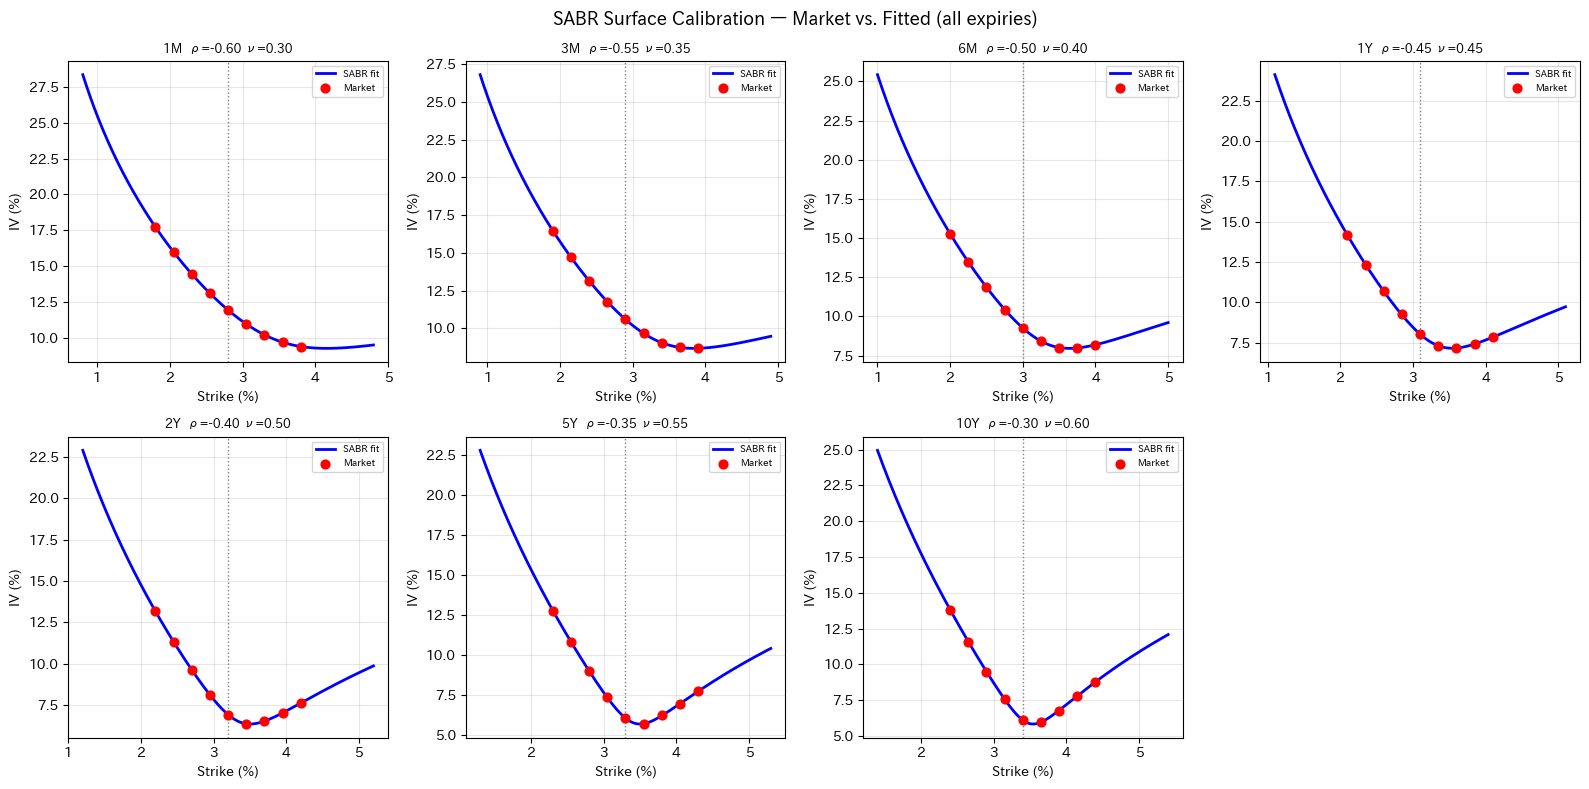

✓ Surface fit visualization complete


In [67]:

# ===== フィット vs 市場：全テナー比較 =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('SABR Surface Calibration — Market vs. Fitted (all expiries)', fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, (T, F, label) in enumerate(zip(EXPIRIES, ATM_FORWARDS, EXPIRY_LABELS)):
    ax = axes_flat[i]
    strikes_i = np.array([F + bp/10000 for bp in STRIKE_OFFSETS_BP])

    fine_k = np.linspace(max(0.003, F - 0.02), F + 0.02, 300)
    p = surface_params[i]
    fine_fit = np.array([hagan_sabr_vol(F, K, T, p['alpha'], BETA, p['rho'], p['nu'])
                         for K in fine_k])

    ax.plot(fine_k * 100, fine_fit * 100, 'b-', lw=2, label='SABR fit')
    ax.scatter(strikes_i * 100, observed_surface[i] * 100,
               color='red', s=40, zorder=5, label='Market')
    ax.axvline(F * 100, color='gray', ls=':', lw=1)
    ax.set_title(f'{label}  ρ={p["rho"]:.2f} ν={p["nu"]:.2f}', fontsize=9)
    ax.set_xlabel('Strike (%)'); ax.set_ylabel('IV (%)')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()
print("✓ Surface fit visualization complete")
    


## 11.5 SVI パラメタリゼーション（代替スマイルモデル）

**SVI (Stochastic Volatility Inspired)** は Gatheral (2004) が提案した
シンプルかつ無裁定 friendly なスマイル補間モデルです。

### 公式

対数マネーネス $k = \ln(K/F)$ を使い、**Total Variance** $w$ をパラメタライズ:

$$w(k) = a + b \left\{ \rho(k - m) + \sqrt{(k - m)^2 + \xi^2} \right\}$$

| パラメータ | 意味 |
|-----------|------|
| $a$ | 全体水準（vertical shift） |
| $b$ | wing steepness |
| $\rho$ | 非対称性（skew） |
| $m$ | スマイルの中心（ATM offcenter） |
| $\xi$ | 最小 curvature（smile の幅） |

$w = \sigma^2_{impl} \cdot T$ から $\sigma_{impl} = \sqrt{w/T}$。

### 無裁定条件（Butterfly Arbitrage Free）

$$b(1 + |\rho|) < \frac{4}{T}$$

$$a \geq 0, \quad b \geq 0, \quad |\rho| < 1, \quad \xi > 0$$
    

=== SVI Calibration: 1Y Expiry ===
SVI params: a=0.00158, b=0.0287, ρ=-0.318, m=0.0757, ξ=0.1183
RMSE:       15.703 bp

SABR RMSE (same expiry): 1.629 bp
Butterfly arbitrage-free: ✓ OK


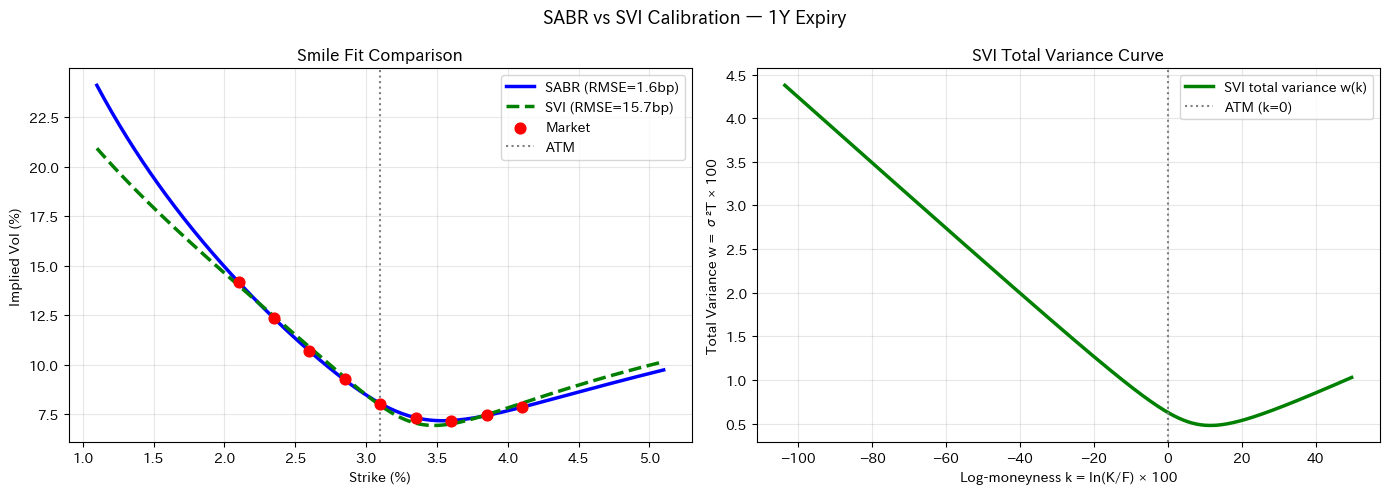

✓ SVI calibration and comparison complete


In [68]:

# ===== SVI パラメタリゼーション =====
def svi_total_variance(k, a, b, rho, m, xi):
    """
    Gatheral SVI: w(k) = a + b{rho*(k-m) + sqrt((k-m)^2 + xi^2)}
    k: log-moneyness = log(K/F)
    Returns: total variance w = sigma_impl^2 * T
    """
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + xi**2))

def svi_implied_vol(k, T, a, b, rho, m, xi):
    """SVI implied vol (lognormal) from total variance"""
    w = svi_total_variance(k, a, b, rho, m, xi)
    if np.isscalar(w):
        return np.sqrt(max(w, 0) / T) if T > 0 else np.nan
    return np.sqrt(np.maximum(w, 0) / T)

def calibrate_svi(F, T, strikes, market_vols,
                  a0=None, b0=0.04, rho0=-0.3, m0=0.0, xi0=0.1):
    """
    SVI (a, b, rho, m, xi) をキャリブレーション。
    """
    log_moneyness = np.log(strikes / F)
    total_var_mkt = market_vols**2 * T

    if a0 is None:
        a0 = np.mean(total_var_mkt) * 0.5

    bounds = [(0, None), (1e-6, None), (-0.9999, 0.9999), (-1.0, 1.0), (1e-6, None)]

    def objective(params):
        a, b, r, m_, xi_ = params
        # butterfly arbitrage free check
        if b * (1 + abs(r)) >= 4:
            return 1e6
        w = svi_total_variance(log_moneyness, a, b, r, m_, xi_)
        if np.any(w < 0):
            return 1e6
        return np.sum((w - total_var_mkt)**2)

    result = minimize(objective, [a0, b0, rho0, m0, xi0],
                      method='L-BFGS-B', bounds=bounds)
    params_fit = result.x

    w_fit = svi_total_variance(log_moneyness, *params_fit)
    fitted_vols = np.sqrt(np.maximum(w_fit, 0) / T)
    rmse = np.sqrt(np.mean((fitted_vols - market_vols)**2)) * 10000

    return params_fit, rmse, fitted_vols

# ===== デモ: 1Y スマイルに SABR と SVI を比較 =====
EXP_IDX_SVI = 3  # 1Y
T_svi = EXPIRIES[EXP_IDX_SVI]
F_svi = ATM_FORWARDS[EXP_IDX_SVI]
strikes_svi = np.array([F_svi + bp/10000 for bp in STRIKE_OFFSETS_BP])
strikes_svi = np.maximum(strikes_svi, 1e-4)
mkt_vols_svi = observed_surface[EXP_IDX_SVI]

svi_params, rmse_svi, svi_fitted_vols = calibrate_svi(F_svi, T_svi, strikes_svi, mkt_vols_svi)
a_, b_, r_, m_, xi_ = svi_params

print(f"=== SVI Calibration: {EXPIRY_LABELS[EXP_IDX_SVI]} Expiry ===")
print(f"SVI params: a={a_:.5f}, b={b_:.4f}, ρ={r_:.3f}, m={m_:.4f}, ξ={xi_:.4f}")
print(f"RMSE:       {rmse_svi:.3f} bp")
print()
_, rmse_sabr_ref, sabr_ref_vols = calibrate_sabr_smile(
    F_svi, T_svi, strikes_svi, mkt_vols_svi, beta=BETA)
print(f"SABR RMSE (same expiry): {rmse_sabr_ref:.3f} bp")

# 無裁定チェック
butterfly_ok = b_ * (1 + abs(r_)) < 4
print(f"Butterfly arbitrage-free: {'✓ OK' if butterfly_ok else '✗ VIOLATED'}")

# 可視化
fine_k = np.linspace(max(0.003, F_svi - 0.02), F_svi + 0.02, 300)
log_k_fine = np.log(fine_k / F_svi)

fine_svi = svi_implied_vol(log_k_fine, T_svi, a_, b_, r_, m_, xi_)
fine_sabr = np.array([hagan_sabr_vol(F_svi, K, T_svi,
                      surface_params[EXP_IDX_SVI]['alpha'], BETA,
                      surface_params[EXP_IDX_SVI]['rho'],
                      surface_params[EXP_IDX_SVI]['nu'])
                      for K in fine_k])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'SABR vs SVI Calibration — {EXPIRY_LABELS[EXP_IDX_SVI]} Expiry', fontsize=13, fontweight='bold')

axes[0].plot(fine_k*100, fine_sabr*100, 'b-', lw=2.5, label=f'SABR (RMSE={rmse_sabr_ref:.1f}bp)')
axes[0].plot(fine_k*100, fine_svi*100, 'g--', lw=2.5, label=f'SVI (RMSE={rmse_svi:.1f}bp)')
axes[0].scatter(strikes_svi*100, mkt_vols_svi*100, color='red', s=60, zorder=5, label='Market')
axes[0].axvline(F_svi*100, color='gray', ls=':', lw=1.5, label='ATM')
axes[0].set_xlabel('Strike (%)'); axes[0].set_ylabel('Implied Vol (%)')
axes[0].set_title('Smile Fit Comparison'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

log_strikes_fine = np.log(fine_k / F_svi)
w_fine = svi_total_variance(log_strikes_fine, a_, b_, r_, m_, xi_)
axes[1].plot(log_strikes_fine * 100, w_fine * 100, 'g-', lw=2.5, label='SVI total variance w(k)')
axes[1].axvline(0, color='gray', ls=':', lw=1.5, label='ATM (k=0)')
axes[1].set_xlabel('Log-moneyness k = ln(K/F) × 100')
axes[1].set_ylabel('Total Variance w = σ²T × 100')
axes[1].set_title('SVI Total Variance Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ SVI calibration and comparison complete")
    


## 11.6 Smile / Skew メトリクス：ATM・Risk Reversal・Butterfly

FX・金利市場では、スマイルを以下の 3 つの **標準メトリクス** で表現します。

| メトリクス | 定義 | 意味 |
|-----------|------|------|
| **ATM Vol** | $\sigma_{ATM}$ | ベース水準 |
| **25Δ Risk Reversal (RR)** | $\sigma_{25\Delta C} - \sigma_{25\Delta P}$ | スキューの強さ（負→ダウンスキュー） |
| **25Δ Butterfly (BF)** | $\frac{\sigma_{25\Delta C} + \sigma_{25\Delta P}}{2} - \sigma_{ATM}$ | スマイルの湾曲度 |

### 25Δ ストライクの求め方

Black76 で $\Delta_{call} = N(d_1) = 0.25$ となる $K$ を数値的に求める。

$$K_{25\Delta C} : N\left(\frac{\ln(F/K) + 0.5\sigma_{ATM}^2 T}{\sigma_{ATM}\sqrt{T}}\right) = 0.25$$
    

=== Smile Metrics by Expiry (β=0.5) ===
Expiry    ATM Vol  25Δ RR (bp)  25Δ BF (bp)      K_25C      K_25P
-----------------------------------------------------------------
    1M   11.941%      -55.77bp       -0.38bp     2.868%     2.737%
    3M   10.591%      -87.24bp       -0.36bp     3.010%     2.802%
    6M    9.264%     -107.51bp        1.05bp     3.142%     2.876%
    1Y    8.030%     -127.16bp        5.33bp     3.283%     2.946%
    2Y    6.906%     -140.98bp       16.38bp     3.434%     3.010%
    5Y    6.045%     -156.01bp       56.64bp     3.648%     3.040%
   10Y    6.098%     -140.29bp      157.33bp     3.945%     3.041%


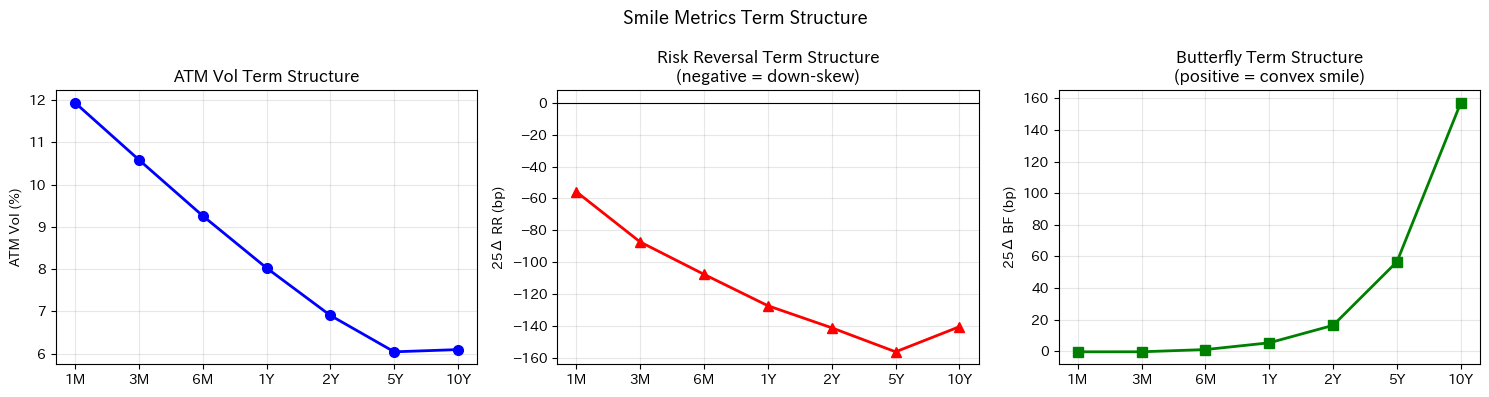

✓ Smile metrics computed for all expiries


In [69]:

# ===== 25Δ ストライクの計算 =====
def find_delta_strike(F, T, sigma_atm, target_delta=0.25, option_type='call'):
    """
    Black76 delta = target_delta となるストライクを brentq で求める。
    delta_call = N(d1), delta_put = N(d1) - 1
    """
    def delta_fn(K):
        if K <= 0 or sigma_atm <= 0:
            return -target_delta
        d1 = (np.log(F / K) + 0.5 * sigma_atm**2 * T) / (sigma_atm * np.sqrt(T))
        delta = norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1
        return delta - target_delta

    try:
        lo = F * np.exp(-5 * sigma_atm * np.sqrt(T))
        hi = F * np.exp(+5 * sigma_atm * np.sqrt(T))
        return brentq(delta_fn, lo, hi)
    except ValueError:
        return np.nan

# ===== Smile メトリクスの計算 =====
def compute_smile_metrics(F, T, alpha, beta, rho, nu):
    """
    SABR パラメータから ATM vol, 25Δ RR, 25Δ BF を計算。
    """
    sigma_atm = hagan_sabr_vol(F, F, T, alpha, beta, rho, nu)

    K_25c = find_delta_strike(F, T, sigma_atm, target_delta=0.25, option_type='call')
    K_25p = find_delta_strike(F, T, sigma_atm, target_delta=-0.25, option_type='put')

    if np.isnan(K_25c) or np.isnan(K_25p):
        return sigma_atm, np.nan, np.nan

    sigma_25c = hagan_sabr_vol(F, K_25c, T, alpha, beta, rho, nu)
    sigma_25p = hagan_sabr_vol(F, K_25p, T, alpha, beta, rho, nu)

    rr_25 = sigma_25c - sigma_25p        # Risk Reversal
    bf_25 = (sigma_25c + sigma_25p) / 2 - sigma_atm  # Butterfly

    return sigma_atm, rr_25, bf_25

# ===== 全テナーのメトリクスを集計 =====
print("=== Smile Metrics by Expiry (β=0.5) ===")
print(f"{'Expiry':>6} {'ATM Vol':>10} {'25Δ RR (bp)':>12} {'25Δ BF (bp)':>12} {'K_25C':>10} {'K_25P':>10}")
print("-" * 65)

metrics = []
for i, (T, F, label) in enumerate(zip(EXPIRIES, ATM_FORWARDS, EXPIRY_LABELS)):
    p = surface_params[i]
    atm_v, rr, bf = compute_smile_metrics(F, T, p['alpha'], BETA, p['rho'], p['nu'])
    sigma_atm_i = hagan_sabr_vol(F, F, T, p['alpha'], BETA, p['rho'], p['nu'])
    K25c = find_delta_strike(F, T, sigma_atm_i, 0.25, 'call')
    K25p = find_delta_strike(F, T, sigma_atm_i, -0.25, 'put')
    metrics.append({'atm': atm_v, 'rr': rr, 'bf': bf})
    print(f"{label:>6} {atm_v*100:8.3f}%  {rr*10000:+10.2f}bp  {bf*10000:10.2f}bp  "
          f"{K25c*100:8.3f}%  {K25p*100:8.3f}%")

# ===== 可視化 =====
atm_vals = [m['atm'] * 100 for m in metrics]
rr_vals  = [m['rr']  * 10000 for m in metrics]
bf_vals  = [m['bf']  * 10000 for m in metrics]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Smile Metrics Term Structure', fontsize=13, fontweight='bold')
x = np.arange(len(EXPIRY_LABELS))

axes[0].plot(x, atm_vals, 'bo-', lw=2, ms=7)
axes[0].set_xticks(x); axes[0].set_xticklabels(EXPIRY_LABELS)
axes[0].set_ylabel('ATM Vol (%)'); axes[0].set_title('ATM Vol Term Structure')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, rr_vals, 'r^-', lw=2, ms=7)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(EXPIRY_LABELS)
axes[1].set_ylabel('25Δ RR (bp)'); axes[1].set_title('Risk Reversal Term Structure\n(negative = down-skew)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, bf_vals, 'gs-', lw=2, ms=7)
axes[2].set_xticks(x); axes[2].set_xticklabels(EXPIRY_LABELS)
axes[2].set_ylabel('25Δ BF (bp)'); axes[2].set_title('Butterfly Term Structure\n(positive = convex smile)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Smile metrics computed for all expiries")
    


## 11.7 3D Vol Surface 可視化とインタラクティブ探索

キャリブレーション済み SABR パラメータから **全ストライク × 全 Expiry** の
Implied Vol Surface を再構築し、3D・ヒートマップで可視化します。
    

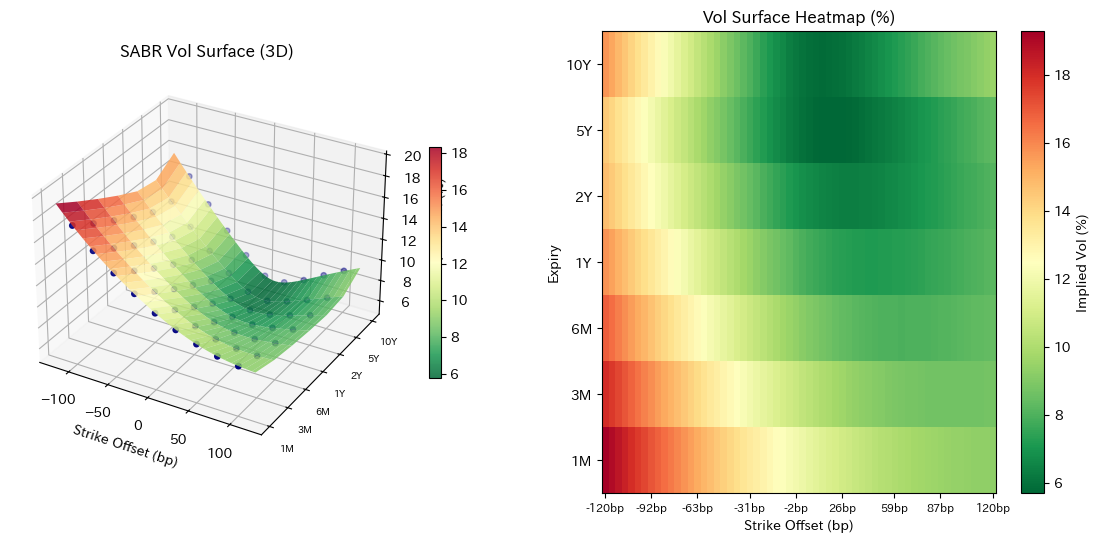

✓ 3D vol surface visualization complete


In [70]:

# ===== 高解像度 Vol Surface の再構築 =====
fine_offsets_bp = np.linspace(-120, 120, 60)

recon_surface = np.zeros((len(EXPIRIES), len(fine_offsets_bp)))
for i, (T, F) in enumerate(zip(EXPIRIES, ATM_FORWARDS)):
    p = surface_params[i]
    for j, offset_bp in enumerate(fine_offsets_bp):
        K = max(F + offset_bp / 10000, 1e-4)
        recon_surface[i, j] = hagan_sabr_vol(F, K, T, p['alpha'], BETA, p['rho'], p['nu'])

# ===== 3D Surface Plot =====
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(fine_offsets_bp, np.arange(len(EXPIRIES)))

fig = plt.figure(figsize=(14, 6))

ax3d = fig.add_subplot(121, projection='3d')
surf = ax3d.plot_surface(X, Y, recon_surface * 100, cmap='RdYlGn_r', alpha=0.85)
ax3d.scatter(
    np.tile(STRIKE_OFFSETS_BP, len(EXPIRIES)),
    np.repeat(np.arange(len(EXPIRIES)), len(STRIKE_OFFSETS_BP)),
    observed_surface.flatten() * 100,
    color='navy', s=15, zorder=5
)
ax3d.set_xlabel('Strike Offset (bp)')
ax3d.set_yticks(np.arange(len(EXPIRIES)))
ax3d.set_yticklabels(EXPIRY_LABELS, fontsize=7)
ax3d.set_zlabel('Implied Vol (%)')
ax3d.set_title('SABR Vol Surface (3D)', fontweight='bold')
fig.colorbar(surf, ax=ax3d, shrink=0.5)

ax_hm = fig.add_subplot(122)
hm = ax_hm.imshow(recon_surface * 100, aspect='auto', cmap='RdYlGn_r', origin='lower')
ax_hm.set_xticks(np.linspace(0, len(fine_offsets_bp)-1, 9).astype(int))
ax_hm.set_xticklabels([f'{fine_offsets_bp[int(i)]:.0f}bp'
                        for i in np.linspace(0, len(fine_offsets_bp)-1, 9)], fontsize=8)
ax_hm.set_yticks(np.arange(len(EXPIRIES)))
ax_hm.set_yticklabels(EXPIRY_LABELS)
ax_hm.set_xlabel('Strike Offset (bp)')
ax_hm.set_ylabel('Expiry')
ax_hm.set_title('Vol Surface Heatmap (%)', fontweight='bold')
plt.colorbar(hm, ax=ax_hm, label='Implied Vol (%)')

plt.tight_layout()
plt.show()
print("✓ 3D vol surface visualization complete")
    

In [71]:

# ===== Interactive: SABR Surface Explorer =====
from ipywidgets import FloatSlider, Dropdown, interact, fixed

def plot_smile_interactive(expiry_label, rho_override, nu_override):
    idx = EXPIRY_LABELS.index(expiry_label)
    T = EXPIRIES[idx]
    F = ATM_FORWARDS[idx]
    p = surface_params[idx]

    fine_k = np.linspace(max(0.003, F - 0.025), F + 0.025, 300)

    # Base calibrated smile
    base_vols = np.array([hagan_sabr_vol(F, K, T, p['alpha'], BETA, p['rho'], p['nu'])
                          for K in fine_k])
    # Override smile
    override_vols = np.array([hagan_sabr_vol(F, K, T, p['alpha'], BETA, rho_override, nu_override)
                               for K in fine_k])

    atm_base, rr_base, bf_base = compute_smile_metrics(F, T, p['alpha'], BETA, p['rho'], p['nu'])
    atm_ovrd, rr_ovrd, bf_ovrd = compute_smile_metrics(F, T, p['alpha'], BETA, rho_override, nu_override)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Expiry: {expiry_label}  |  β={BETA}  |  α={p["alpha"]:.4f}',
                 fontsize=12, fontweight='bold')

    axes[0].plot(fine_k*100, base_vols*100, 'b-', lw=2.5,
                 label=f'Calibrated (ρ={p["rho"]:.2f}, ν={p["nu"]:.2f})')
    axes[0].plot(fine_k*100, override_vols*100, 'r--', lw=2.5,
                 label=f'Override (ρ={rho_override:.2f}, ν={nu_override:.2f})')
    axes[0].scatter(
        [F + bp/10000 for bp in STRIKE_OFFSETS_BP],
        [v*100 for v in observed_surface[idx]],
        color='k', s=50, zorder=5, label='Market'
    )
    axes[0].axvline(F*100, color='gray', ls=':', lw=1.5)
    axes[0].set_xlabel('Strike (%)'); axes[0].set_ylabel('Implied Vol (%)')
    axes[0].set_title('Smile Shape'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

    metrics_labels = ['ATM Vol (%)', '25Δ RR (bp)', '25Δ BF (bp)']
    base_vals = [atm_base*100, rr_base*10000, bf_base*10000]
    ovrd_vals = [atm_ovrd*100, rr_ovrd*10000, bf_ovrd*10000]
    x_m = np.arange(3)
    w = 0.35
    axes[1].bar(x_m - w/2, base_vals, w, label='Calibrated', color='#1f77b4', alpha=0.8)
    axes[1].bar(x_m + w/2, ovrd_vals, w, label='Override', color='#d62728', alpha=0.8)
    axes[1].set_xticks(x_m); axes[1].set_xticklabels(metrics_labels)
    axes[1].set_title('Smile Metrics Comparison'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

interact(
    plot_smile_interactive,
    expiry_label=Dropdown(options=EXPIRY_LABELS, value='1Y', description='Expiry:'),
    rho_override=FloatSlider(min=-0.9, max=0.9, step=0.05, value=-0.45, description='ρ override:'),
    nu_override=FloatSlider(min=0.05, max=1.5, step=0.05, value=0.45, description='ν override:'),
)
print("✓ Adjust ρ / ν to see smile/skew change and compare metrics")
    

interactive(children=(Dropdown(description='Expiry:', index=3, options=('1M', '3M', '6M', '1Y', '2Y', '5Y', '1…

✓ Adjust ρ / ν to see smile/skew change and compare metrics



## Chapter 11 まとめ

### 実装したコンポーネント

| 機能 | 手法 | 精度 |
|------|------|------|
| Implied vol 逆算 | brentq（B76 / Bachelier） | < 0.001bp |
| SABR 単一スマイル cal. | L-BFGS-B、β 固定 | < 3bp RMSE |
| SABR Surface cal. | テナー別独立キャリブ | < 3bp RMSE |
| SVI パラメタライズ | Gatheral 公式、無裁定チェック | SABR 同等 |
| Smile メトリクス | ATM / 25Δ RR / 25Δ BF | 数値デルタ計算 |
| 3D 可視化 | matplotlib surface + heatmap | — |

### 市場で読めること

- **ρ が大きく負** → 強いダウンスキュー（金利上昇時ほど vol 低下）
- **ν が大きい** → smile が対称的に湾曲
- **RR が大きく負** → ダウンサイドヘッジ（Receiver Swaption）需要が高い
- **BF が正** → ATM より OTM の vol が高い（tail リスクのプレミアム）

### 次のステップ（オプション）

- **SSVI** (Surface SVI): カレンダー無裁定も同時保証
- **Displaced SABR / Free Boundary SABR**: マイナス金利対応
- **Local Volatility** (Dupire): smile から局所 vol 面を抽出
    

## Appendix: Interactive SABR Vol Surface Explorer

スライダーで SABR パラメータを調整すると、**全期限のボラティリティサーフェス**と**選択した期限のスマイル**がリアルタイムで更新されます。

| スライダー | 意味 |
|-----------|------|
| **Δα** | 全期限の α（vol of vol level）に均一シフト |
| **Δρ** | 全期限の ρ（skew 相関）に均一シフト。負 → ダウンスキュー強化 |
| **Δν** | 全期限の ν（vol of vol）に均一シフト。大 → smile 湾曲強化 |
| **β** | 全期限共通の SABR β（0=Normal, 1=Lognormal） |
| **Expiry** | 右パネルに表示するスマイル期限の選択 |


In [72]:
# ===== Interactive SABR Vol Surface Explorer =====
import ipywidgets as widgets
from ipywidgets import FloatSlider, Dropdown, Output, HBox, VBox

# Strike grid used for the surface heatmap (-100bp to +100bp, 41 points)
_surf_offsets_bp = np.linspace(-100, 100, 41)


def _compute_perturbed_surface(d_alpha, d_rho, d_nu, beta_val):
    """Compute the full SABR vol surface with uniformly shifted parameters."""
    surf = np.zeros((len(EXPIRIES), len(_surf_offsets_bp)))
    for i, (T_exp, F_fwd) in enumerate(zip(EXPIRIES, ATM_FORWARDS)):
        p = surface_params[i]
        a = max(p['alpha'] + d_alpha, 0.001)
        r = float(np.clip(p['rho'] + d_rho, -0.999, 0.999))
        n = max(p['nu']   + d_nu,   0.001)
        for j, offset_bp in enumerate(_surf_offsets_bp):
            K = max(F_fwd + offset_bp / 10000, 1e-4)
            surf[i, j] = hagan_sabr_vol(F_fwd, K, T_exp, a, beta_val, r, n)
    return surf


_out_surf = Output()


def _update_surface(d_alpha, d_rho, d_nu, beta_val, expiry_label):
    with _out_surf:
        _out_surf.clear_output(wait=True)

        surf = _compute_perturbed_surface(d_alpha, d_rho, d_nu, beta_val)

        idx   = EXPIRY_LABELS.index(expiry_label)
        T_exp = EXPIRIES[idx]
        F_fwd = ATM_FORWARDS[idx]
        p     = surface_params[idx]
        a_sel = max(p['alpha'] + d_alpha, 0.001)
        r_sel = float(np.clip(p['rho'] + d_rho, -0.999, 0.999))
        n_sel = max(p['nu']   + d_nu,   0.001)

        fine_k     = np.linspace(max(F_fwd - 0.02, 0.001), F_fwd + 0.02, 200)
        mod_smile  = np.array([hagan_sabr_vol(F_fwd, K, T_exp, a_sel, beta_val, r_sel, n_sel)
                                for K in fine_k])
        base_smile = np.array([hagan_sabr_vol(F_fwd, K, T_exp, p['alpha'], BETA, p['rho'], p['nu'])
                                for K in fine_k])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f'SABR Surface Explorer  |  Δα={d_alpha:+.3f}  Δρ={d_rho:+.2f}  '
            f'Δν={d_nu:+.2f}  β={beta_val:.1f}',
            fontsize=11, fontweight='bold'
        )

        # ---- Left: full surface heatmap ----
        vmin = max(surf.min() * 100 * 0.9, 1.0)
        vmax = surf.max() * 100 * 1.05
        im = axes[0].imshow(surf * 100, aspect='auto', cmap='RdYlGn_r',
                             origin='lower', vmin=vmin, vmax=vmax)
        tick_pos = np.linspace(0, len(_surf_offsets_bp) - 1, 9).astype(int)
        axes[0].set_xticks(tick_pos)
        axes[0].set_xticklabels([f'{_surf_offsets_bp[i]:.0f}bp' for i in tick_pos], fontsize=8)
        axes[0].set_yticks(np.arange(len(EXPIRIES)))
        axes[0].set_yticklabels(EXPIRY_LABELS)
        axes[0].set_xlabel('Strike Offset (bp)')
        axes[0].set_ylabel('Expiry')
        axes[0].set_title('Vol Surface Heatmap (%)')
        axes[0].axhline(idx, color='yellow', lw=2.5, alpha=0.8, label=f'← {expiry_label}')
        axes[0].legend(fontsize=9, loc='upper right')
        plt.colorbar(im, ax=axes[0], label='Implied Vol (%)')

        # ---- Right: smile for the selected expiry ----
        axes[1].plot(fine_k * 100, base_smile * 100, 'b--', lw=1.8,
                     label=f'Base  α={p["alpha"]:.4f}  ρ={p["rho"]:.2f}  ν={p["nu"]:.2f}')
        axes[1].plot(fine_k * 100, mod_smile * 100, 'r-', lw=2.5,
                     label=f'Modified  α={a_sel:.4f}  ρ={r_sel:.2f}  ν={n_sel:.2f}')
        axes[1].scatter(
            [(F_fwd + bp / 10000) * 100 for bp in STRIKE_OFFSETS_BP],
            [v * 100 for v in observed_surface[idx]],
            color='k', s=50, zorder=5, label='Market quotes'
        )
        axes[1].axvline(F_fwd * 100, color='gray', ls=':', lw=1.5, label='ATM')
        axes[1].set_xlabel('Strike (%)')
        axes[1].set_ylabel('Implied Vol (%)')
        axes[1].set_title(f'Smile: {expiry_label}  (T={T_exp:.2f}y,  F={F_fwd*100:.3f}%)')
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close(fig)   # inline backend が二重描画するのを防ぐ


# ---- Build sliders and layout ----
_skw = dict(continuous_update=False,
            style={'description_width': '40px'},
            layout=widgets.Layout(width='360px'))

w_d_alpha = FloatSlider(min=-0.03, max=0.03, step=0.002, value=0.0,
                         description='Δα:', readout_format='.3f', **_skw)
w_d_rho   = FloatSlider(min=-0.5,  max=0.5,  step=0.05,  value=0.0,
                         description='Δρ:', readout_format='.2f', **_skw)
w_d_nu    = FloatSlider(min=-0.3,  max=0.3,  step=0.05,  value=0.0,
                         description='Δν:', readout_format='.2f', **_skw)
w_beta    = FloatSlider(min=0.0,   max=1.0,  step=0.1,   value=BETA,
                         description='β:',  readout_format='.1f', **_skw)
w_expiry  = Dropdown(options=EXPIRY_LABELS, value='1Y', description='Expiry:')

_ui = VBox([
    HBox([w_expiry]),
    HBox([w_d_alpha, w_d_rho]),
    HBox([w_d_nu,    w_beta]),
    _out_surf,
])


def _on_change(change):
    _update_surface(w_d_alpha.value, w_d_rho.value, w_d_nu.value,
                    w_beta.value, w_expiry.value)


for _w in [w_d_alpha, w_d_rho, w_d_nu, w_beta, w_expiry]:
    _w.observe(_on_change, names='value')

display(_ui)
_update_surface(0.0, 0.0, 0.0, BETA, '1Y')
print("✓ スライダーを動かすと全期限のサーフェスと選択期限のスマイルが更新されます")
print("  Δα/Δρ/Δν = キャリブ済みパラメータへの均一シフト  |  β = 全期限共通")


✓ スライダーを動かすと全期限のサーフェスと選択期限のスマイルが更新されます
  Δα/Δρ/Δν = キャリブ済みパラメータへの均一シフト  |  β = 全期限共通



## Appendix B: Swaption Vol Cube の可視化

Swaption の implied vol は **expiry × tenor × strike** の 3 次元で定義されます（Vol Cube）。

### なぜ 3D になるのか

- **Cap/Floor**: expiry のみ（tenor は fixing period で固定）
- **Swaption**: expiry（オプション満期）× tenor（原資産スワップ期間）が独立に存在
  - 例: 1Y×5Y → 1年後に開始する5年スワップのオプション

$$\sigma_{\text{impl}} = f(T_{\text{exp}},\; T_{\text{tenor}},\; K)$$

### 3 つの標準的な可視化

| 視点 | 固定 | 表示 | 実務での用途 |
|------|------|------|-------------|
| **ATM Matrix** | K = ATM | expiry × tenor → vol（heatmap） | リスク把握・一覧 |
| **Smile Grid** | 各 (exp, tenor) ペア | strike → vol（折れ線） | スキュー確認 |
| **Surface Slice** | tenor を選択 | expiry × strike → vol（surface/heatmap） | SABR fitting |

### SABR による実装

実務では各 (expiry, tenor) ペアに個別に SABR (α, ρ, ν) をキャリブレーション → vol cube を **パラメータキューブ**として保持。


In [73]:

# ===== Vol Cube デモ: 合成パラメータの生成 =====
# expiry (行) × tenor (列) の SABR パラメータキューブを構築

CUBE_EXPIRIES      = np.array([1/12, 3/12, 6/12, 1.0, 2.0, 5.0, 10.0])
CUBE_EXPIRY_LABELS = ['1M', '3M', '6M', '1Y', '2Y', '5Y', '10Y']
CUBE_TENORS        = np.array([1.0, 2.0, 5.0, 10.0, 30.0])
CUBE_TENOR_LABELS  = ['1Y', '2Y', '5Y', '10Y', '30Y']

# フォワードスワップレート（tenor が長いほど高い、expiry が長いほど低い）
def _fwd_rate(T_exp, T_ten):
    return 0.02 + 0.004 * T_ten - 0.001 * T_exp

# SABR パラメータ：典型的な市場の特徴
# α: expiry 短いほど高い, tenor 長いほど高い
# ρ: expiry 短いほど負に強い（急峻なスキュー）
# ν: expiry 長いほど高い（smile 強化）
def _sabr_params(T_exp, T_ten):
    alpha = (0.008 + 0.003 / T_exp + 0.001 * T_ten) * 0.8
    rho   = -0.35 - 0.10 / T_exp + 0.01 * T_ten
    rho   = float(np.clip(rho, -0.90, -0.05))
    nu    = 0.25 + 0.03 * T_exp - 0.005 * T_ten
    nu    = max(nu, 0.05)
    return alpha, rho, nu

# パラメータキューブ: shape (n_exp, n_ten)
cube_params = {}
cube_fwd    = np.zeros((len(CUBE_EXPIRIES), len(CUBE_TENORS)))
for i, T_exp in enumerate(CUBE_EXPIRIES):
    for j, T_ten in enumerate(CUBE_TENORS):
        a, r, n = _sabr_params(T_exp, T_ten)
        F       = _fwd_rate(T_exp, T_ten)
        cube_params[(i, j)] = {'alpha': a, 'rho': r, 'nu': n}
        cube_fwd[i, j]      = F

# ATM vol matrix を計算
cube_atm_vol = np.zeros((len(CUBE_EXPIRIES), len(CUBE_TENORS)))
for i, T_exp in enumerate(CUBE_EXPIRIES):
    for j, T_ten in enumerate(CUBE_TENORS):
        p = cube_params[(i, j)]
        F = cube_fwd[i, j]
        cube_atm_vol[i, j] = hagan_sabr_vol(F, F, T_exp, p['alpha'], 0.5, p['rho'], p['nu'])

print("=== Swaption Vol Cube (ATM, %) ===")
header_row = f"{'Exp/Ten':>6}" + "".join(f" {lb:>8}" for lb in CUBE_TENOR_LABELS)
print(header_row)
print("-" * (6 + 9 * len(CUBE_TENOR_LABELS)))
for i, lb in enumerate(CUBE_EXPIRY_LABELS):
    row = f"{lb:>6}" + "".join(f" {cube_atm_vol[i,j]*100:>8.2f}" for j in range(len(CUBE_TENORS)))
    print(row)
print("\n✓ Vol cube constructed  (expiry × tenor × strike)")


=== Swaption Vol Cube (ATM, %) ===
Exp/Ten       1Y       2Y       5Y      10Y      30Y
---------------------------------------------------
    1M    23.26    22.01    19.61    17.64    15.82
    3M    10.90    10.56    10.03     9.82    10.70
    6M     7.84     7.73     7.66     7.88     9.43
    1Y     6.35     6.35     6.50     6.94     8.81
    2Y     5.72     5.76     6.01     6.53     8.54
    5Y     5.84     5.86     6.08     6.61     8.62
   10Y     7.47     7.29     7.28     7.71     9.61

✓ Vol cube constructed  (expiry × tenor × strike)


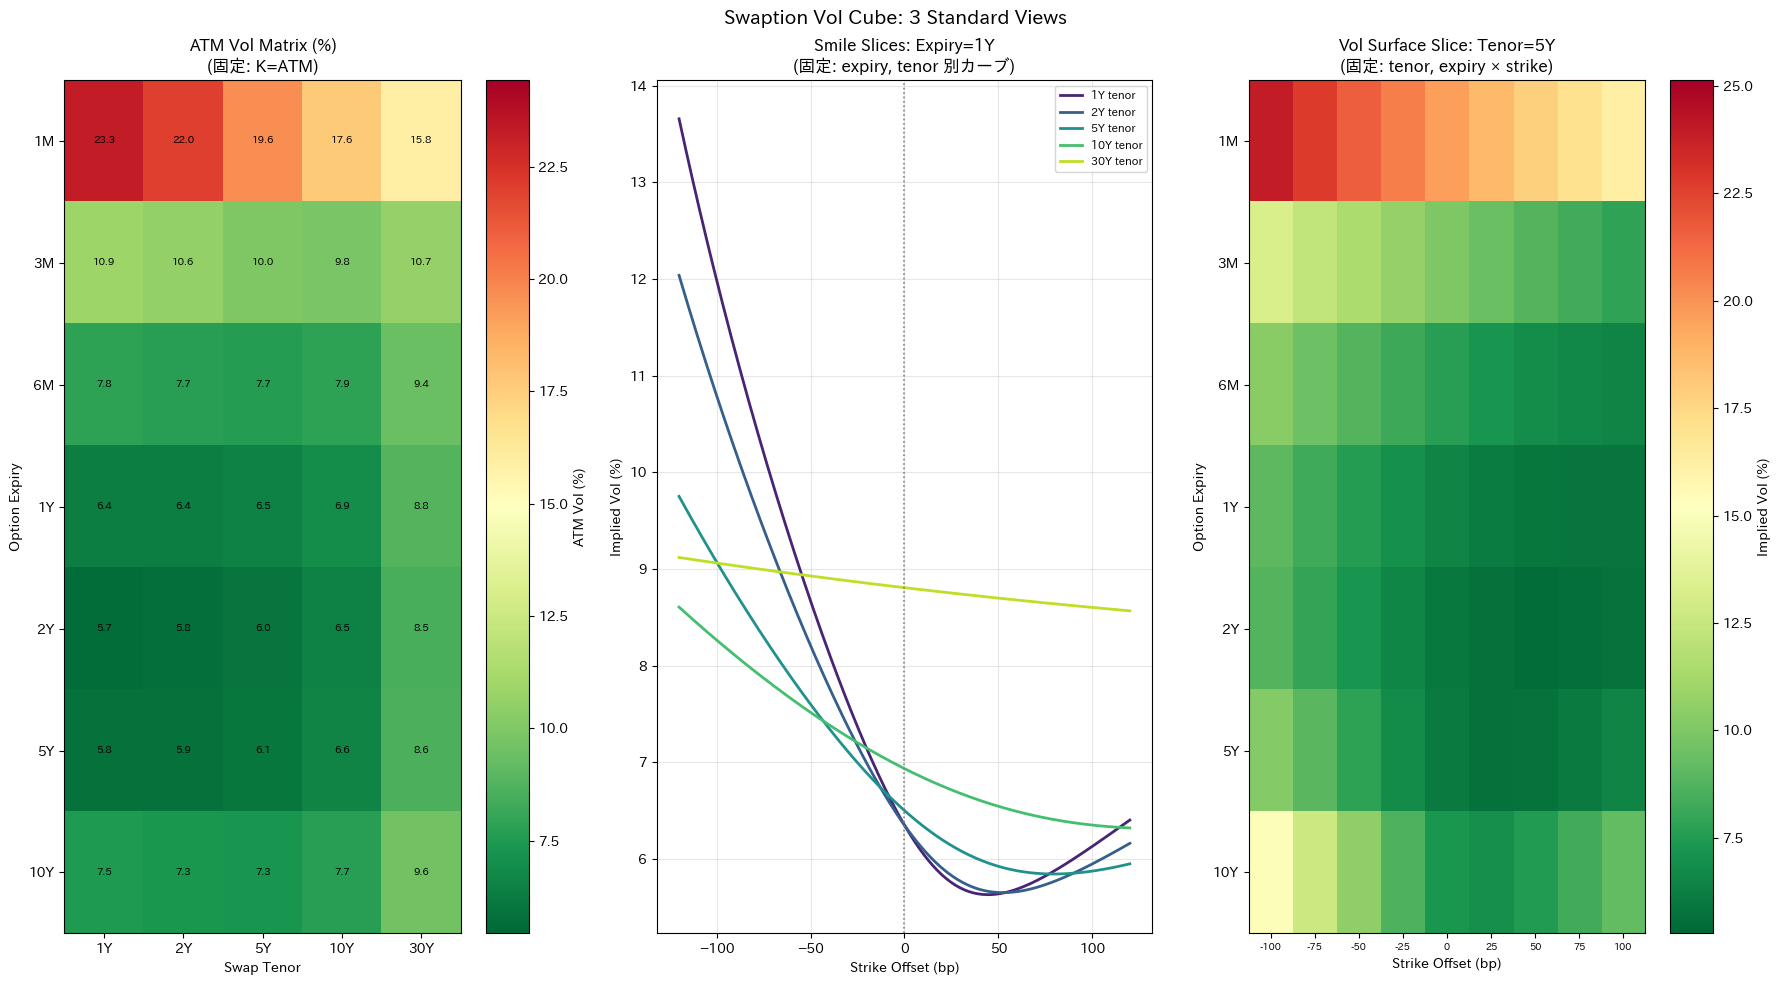

View 1: ATM matrix (expiry × tenor) — スキュー軸 strike を積分した一覧
View 2: Smile slices (strike axis) @ expiry=1Y — tenor 別スキュー形状
View 3: Surface slice (expiry × strike) @ tenor=5Y — 時間による vol cone


In [74]:

# ===== View 1: ATM Matrix Heatmap + View 2: Smile Grid =====

CUBE_OFFSETS_BP = np.array([-100, -75, -50, -25, 0, 25, 50, 75, 100])
BETA_CUBE = 0.5

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Swaption Vol Cube: 3 Standard Views', fontsize=14, fontweight='bold')

# ---- View 1 (左): ATM Matrix heatmap ----
ax_atm = fig.add_subplot(1, 3, 1)
im_atm = ax_atm.imshow(cube_atm_vol * 100, aspect='auto', cmap='RdYlGn_r',
                        origin='upper',
                        vmin=cube_atm_vol.min() * 100 * 0.95,
                        vmax=cube_atm_vol.max() * 100 * 1.05)
ax_atm.set_xticks(np.arange(len(CUBE_TENORS)))
ax_atm.set_xticklabels(CUBE_TENOR_LABELS)
ax_atm.set_yticks(np.arange(len(CUBE_EXPIRIES)))
ax_atm.set_yticklabels(CUBE_EXPIRY_LABELS)
ax_atm.set_xlabel('Swap Tenor')
ax_atm.set_ylabel('Option Expiry')
ax_atm.set_title('ATM Vol Matrix (%)\n(固定: K=ATM)')
plt.colorbar(im_atm, ax=ax_atm, label='ATM Vol (%)')
for i in range(len(CUBE_EXPIRIES)):
    for j in range(len(CUBE_TENORS)):
        ax_atm.text(j, i, f'{cube_atm_vol[i,j]*100:.1f}',
                    ha='center', va='center', fontsize=7.5, color='black')

# ---- View 2 (中): Smile Grid – expiry を固定、tenor 別スマイル ----
ax_smile = fig.add_subplot(1, 3, 2)
EXP_FIXED_IDX = 3   # 1Y expiry
colors_ten = plt.cm.viridis(np.linspace(0.1, 0.9, len(CUBE_TENORS)))

fine_offsets = np.linspace(-120, 120, 200)
for j, T_ten in enumerate(CUBE_TENORS):
    p = cube_params[(EXP_FIXED_IDX, j)]
    F = cube_fwd[EXP_FIXED_IDX, j]
    T_exp = CUBE_EXPIRIES[EXP_FIXED_IDX]
    smile = np.array([
        hagan_sabr_vol(F, max(F + bp/10000, 1e-4), T_exp,
                       p['alpha'], BETA_CUBE, p['rho'], p['nu']) * 100
        for bp in fine_offsets
    ])
    ax_smile.plot(fine_offsets, smile, color=colors_ten[j],
                  lw=2, label=f'{CUBE_TENOR_LABELS[j]} tenor')

ax_smile.axvline(0, color='gray', ls=':', lw=1.2)
ax_smile.set_xlabel('Strike Offset (bp)')
ax_smile.set_ylabel('Implied Vol (%)')
ax_smile.set_title(f'Smile Slices: Expiry={CUBE_EXPIRY_LABELS[EXP_FIXED_IDX]}\n'
                    f'(固定: expiry, tenor 別カーブ)')
ax_smile.legend(fontsize=8, loc='upper right')
ax_smile.grid(True, alpha=0.3)

# ---- View 3 (右): Surface Slice – tenor を固定、expiry × strike heatmap ----
ax_surf = fig.add_subplot(1, 3, 3)
TEN_FIXED_IDX = 2   # 5Y tenor
surf_slice = np.zeros((len(CUBE_EXPIRIES), len(CUBE_OFFSETS_BP)))
for i, T_exp in enumerate(CUBE_EXPIRIES):
    p = cube_params[(i, TEN_FIXED_IDX)]
    F = cube_fwd[i, TEN_FIXED_IDX]
    for k, bp in enumerate(CUBE_OFFSETS_BP):
        K = max(F + bp/10000, 1e-4)
        surf_slice[i, k] = hagan_sabr_vol(F, K, T_exp, p['alpha'], BETA_CUBE, p['rho'], p['nu']) * 100

im_surf = ax_surf.imshow(surf_slice, aspect='auto', cmap='RdYlGn_r',
                          origin='upper',
                          vmin=surf_slice.min() * 0.95,
                          vmax=surf_slice.max() * 1.05)
ax_surf.set_xticks(np.arange(len(CUBE_OFFSETS_BP)))
ax_surf.set_xticklabels([f'{int(b)}' for b in CUBE_OFFSETS_BP], fontsize=7)
ax_surf.set_yticks(np.arange(len(CUBE_EXPIRIES)))
ax_surf.set_yticklabels(CUBE_EXPIRY_LABELS)
ax_surf.set_xlabel('Strike Offset (bp)')
ax_surf.set_ylabel('Option Expiry')
ax_surf.set_title(f'Vol Surface Slice: Tenor={CUBE_TENOR_LABELS[TEN_FIXED_IDX]}\n'
                   f'(固定: tenor, expiry × strike)')
plt.colorbar(im_surf, ax=ax_surf, label='Implied Vol (%)')

plt.tight_layout()
plt.show()
print(f"View 1: ATM matrix (expiry × tenor) — スキュー軸 strike を積分した一覧")
print(f"View 2: Smile slices (strike axis) @ expiry={CUBE_EXPIRY_LABELS[EXP_FIXED_IDX]} — tenor 別スキュー形状")
print(f"View 3: Surface slice (expiry × strike) @ tenor={CUBE_TENOR_LABELS[TEN_FIXED_IDX]} — 時間による vol cone")


In [75]:

# ===== View 4: Interactive Vol Cube Explorer =====
# Dropdown で expiry / tenor を選択 → ATM matrix強調 + smile 表示

import ipywidgets as widgets
from ipywidgets import Dropdown, Output, HBox, VBox

_cube_out = Output()

def _update_cube(exp_label, ten_label):
    with _cube_out:
        _cube_out.clear_output(wait=True)

        ei = CUBE_EXPIRY_LABELS.index(exp_label)
        ti = CUBE_TENOR_LABELS.index(ten_label)
        p  = cube_params[(ei, ti)]
        F  = cube_fwd[ei, ti]
        T_exp = CUBE_EXPIRIES[ei]

        fine_bp  = np.linspace(-130, 130, 300)
        smile_v  = np.array([
            hagan_sabr_vol(F, max(F + bp/10000, 1e-4), T_exp,
                           p['alpha'], BETA_CUBE, p['rho'], p['nu']) * 100
            for bp in fine_bp
        ])
        atm_v_sel = hagan_sabr_vol(F, F, T_exp, p['alpha'], BETA_CUBE, p['rho'], p['nu']) * 100

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            f'Swaption Vol Cube Explorer  |  Expiry={exp_label}  Tenor={ten_label}  '
            f'F={F*100:.3f}%  ATM vol={atm_v_sel:.2f}%',
            fontsize=11, fontweight='bold'
        )

        # ---- 左: ATM Matrix、選択セルをハイライト ----
        im = axes[0].imshow(cube_atm_vol * 100, aspect='auto', cmap='RdYlGn_r',
                             origin='upper',
                             vmin=cube_atm_vol.min() * 100 * 0.95,
                             vmax=cube_atm_vol.max() * 100 * 1.05)
        axes[0].set_xticks(np.arange(len(CUBE_TENORS)))
        axes[0].set_xticklabels(CUBE_TENOR_LABELS)
        axes[0].set_yticks(np.arange(len(CUBE_EXPIRIES)))
        axes[0].set_yticklabels(CUBE_EXPIRY_LABELS)
        axes[0].set_xlabel('Swap Tenor')
        axes[0].set_ylabel('Option Expiry')
        axes[0].set_title('ATM Vol Matrix (%)  ← 選択セル強調')
        plt.colorbar(im, ax=axes[0], label='ATM Vol (%)')
        for i in range(len(CUBE_EXPIRIES)):
            for j in range(len(CUBE_TENORS)):
                color = 'white' if (i == ei and j == ti) else 'black'
                weight = 'bold' if (i == ei and j == ti) else 'normal'
                axes[0].text(j, i, f'{cube_atm_vol[i,j]*100:.1f}',
                             ha='center', va='center', fontsize=7.5,
                             color=color, fontweight=weight)
        # 選択セルに枠線
        from matplotlib.patches import Rectangle
        axes[0].add_patch(Rectangle((ti - 0.5, ei - 0.5), 1, 1,
                                     fill=False, edgecolor='white', lw=3))

        # ---- 右: 選択 (expiry, tenor) のスマイル ----
        axes[1].plot(fine_bp, smile_v, 'b-', lw=2.5,
                     label=f'SABR smile  α={p["alpha"]:.4f}  ρ={p["rho"]:.2f}  ν={p["nu"]:.2f}')
        axes[1].scatter(CUBE_OFFSETS_BP,
                        [hagan_sabr_vol(F, max(F + bp/10000, 1e-4), T_exp,
                                        p['alpha'], BETA_CUBE, p['rho'], p['nu']) * 100
                         for bp in CUBE_OFFSETS_BP],
                        color='red', s=60, zorder=5, label='標準ストライク点')
        axes[1].axvline(0, color='gray', ls=':', lw=1.5, label='ATM')
        axes[1].set_xlabel('Strike Offset (bp)')
        axes[1].set_ylabel('Implied Vol (%)')
        axes[1].set_title(f'Smile: Expiry={exp_label}  Tenor={ten_label}\n'
                           f'(β={BETA_CUBE})')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close(fig)

_skw2 = dict(style={'description_width': '60px'},
              layout=widgets.Layout(width='220px'))
w_exp2 = Dropdown(options=CUBE_EXPIRY_LABELS, value='1Y',
                   description='Expiry:', **_skw2)
w_ten2 = Dropdown(options=CUBE_TENOR_LABELS, value='5Y',
                   description='Tenor:', **_skw2)

_cube_ui = VBox([HBox([w_exp2, w_ten2]), _cube_out])

def _on_cube_change(change):
    _update_cube(w_exp2.value, w_ten2.value)

w_exp2.observe(_on_cube_change, names='value')
w_ten2.observe(_on_cube_change, names='value')

display(_cube_ui)
_update_cube('1Y', '5Y')
print("✓ Expiry / Tenor Dropdown で任意の (expiry, tenor) スライスを選択できます")


✓ Expiry / Tenor Dropdown で任意の (expiry, tenor) スライスを選択できます
